In [1]:
import os
import time
import numpy as np
import pandas as pd

import numpy as np
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.metrics import confusion_matrix, f1_score, classification_report, accuracy_score
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.utils import to_categorical
import joblib

import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
from keras.regularizers import l2
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, GlobalMaxPooling1D, Dropout,
    Flatten, Dense, Reshape, LSTM, SimpleRNN, GRU, Bidirectional, Activation
)

from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dropout, Flatten,
    BatchNormalization, DepthwiseConv2D, AveragePooling2D, SeparableConv2D
)

from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data = pd.read_csv("/content/drive/MyDrive/CSNLP/Football/football.csv")
data.head(10)

,comment,sentiment,hate,agression
0,এই কুত্তার বাচ্চা রেফারি পুরা ম্যাচটাই নষ্ট কর...,negative,hate,ag
1,ফাইনাল ম্যাচে জার্মানি বনাম চিলি ম্যাচটা আজ রা...,neutral,normal,nag
2,মেসি এর পজিশনিং আজকে একদমই ভালো ছিল না,negative,normal,nag
3,রেফারির এই সিদ্ধান্ত দেখে দোস্ত মেজাজ খারাপ হয...,negative,hate,ag
4,ভিনিসিয়ুস মাঠে নেমে খালি নাটক করে কিছুই করে না,negative,hate,ag
5,এই রেফারিরে মামা আর কোনদিন মাঠে নামানো ঠিক হবে না,negative,hate,ag
6,রেফারির এই সিদ্ধান্ত দেখে পুরাই মেজাজ খারাপ হয...,negative,hate,ag
7,ট্রান্সফার মার্কেটে সালাহ এর দাম এখন অনেক বেড়...,neutral,normal,nag
8,বেয়াদব খেলোয়াড় স্রেফ একটা দলকে জেতানোর জন্য...,negative,hate,ag
9,ফ্রান্স জিতলেই তাদের সাপোর্টাররা দোস্ত অহংকার ...,negative,hate,ag


In [4]:
data.columns

Index(['comment', 'sentiment', 'hate', 'agression'], dtype='object')

In [5]:
df_processed = data[['comment', 'hate']].copy()
df_processed['hate'] = df_processed['hate'].str.lower()

# Display the first few rows of the processed DataFrame
df_processed.head()

,comment,hate
0,এই কুত্তার বাচ্চা রেফারি পুরা ম্যাচটাই নষ্ট কর...,hate
1,ফাইনাল ম্যাচে জার্মানি বনাম চিলি ম্যাচটা আজ রা...,normal
2,মেসি এর পজিশনিং আজকে একদমই ভালো ছিল না,normal
3,রেফারির এই সিদ্ধান্ত দেখে দোস্ত মেজাজ খারাপ হয...,hate
4,ভিনিসিয়ুস মাঠে নেমে খালি নাটক করে কিছুই করে না,hate


In [6]:
df_processed["hate"].value_counts()

,count
hate,
normal,6763
hate,4800


In [7]:
df_processed["hate"].unique()

array(['hate', 'normal', nan], dtype=object)

In [8]:
df_processed['hate'] = df_processed['hate'].fillna('normal')

In [9]:
df_processed["hate"].unique()

array(['hate', 'normal'], dtype=object)

In [10]:

le = LabelEncoder()
df_processed['encoded_label'] = le.fit_transform(df_processed["hate"])

In [11]:
print(f"Classes learned by LabelEncoder: {le.classes_}")
print(f"Number of classes: {len(le.classes_)}")

Classes learned by LabelEncoder: ['hate' 'normal']
Number of classes: 2


In [12]:
df_processed.head()

,comment,hate,encoded_label
0,এই কুত্তার বাচ্চা রেফারি পুরা ম্যাচটাই নষ্ট কর...,hate,0
1,ফাইনাল ম্যাচে জার্মানি বনাম চিলি ম্যাচটা আজ রা...,normal,1
2,মেসি এর পজিশনিং আজকে একদমই ভালো ছিল না,normal,1
3,রেফারির এই সিদ্ধান্ত দেখে দোস্ত মেজাজ খারাপ হয...,hate,0
4,ভিনিসিয়ুস মাঠে নেমে খালি নাটক করে কিছুই করে না,hate,0


In [13]:
import re

def preprocess_bangla(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'http\S+|www\S+', '', text)          # remove URLs
    text = re.sub(r'<.*?>', '', text)                    # remove HTML tags
    text = re.sub(r'[a-zA-Z]', '', text)                 # remove English letters
    text = re.sub(r'[0-9০-৯]', '', text)                # remove digits
    text = re.sub(r'[^\u0980-\u09FF\s]', '', text)      # keep only Bangla Unicode
    text = re.sub(r'\s+', ' ', text).strip()             # normalize whitespace
    return text

TEXT_COLUMN = 'comment'
LABEL_COLUMN = 'encoded_label'

df_processed['cleaned_text'] = df_processed[TEXT_COLUMN].apply(preprocess_bangla)
df_processed = df_processed[df_processed['cleaned_text'].str.strip() != ''].reset_index(drop=True)

# Tokenize
df_processed['tokens'] = df_processed['cleaned_text'].apply(lambda x: x.split())
corpus = df_processed['tokens'].tolist()

print(f'Samples after cleaning: {len(df_processed)}')
print('\nSample before/after:')
for i in range(3):
    print(f'  Original : {df_processed[TEXT_COLUMN].iloc[i]}')
    print(f'  Cleaned  : {df_processed["cleaned_text"].iloc[i]}')
    print(f'  Tokens   : {df_processed["tokens"].iloc[i]}')
    print()

Samples after cleaning: 11567

Sample before/after:
  Original : এই কুত্তার বাচ্চা রেফারি পুরা ম্যাচটাই নষ্ট করে দিলো
  Cleaned  : এই কুত্তার বাচ্চা রেফারি পুরা ম্যাচটাই নষ্ট করে দিলো
  Tokens   : ['এই', 'কুত্তার', 'বাচ্চা', 'রেফারি', 'পুরা', 'ম্যাচটাই', 'নষ্ট', 'করে', 'দিলো']

  Original : ফাইনাল ম্যাচে জার্মানি বনাম চিলি ম্যাচটা আজ রাতে শুরু হবে
  Cleaned  : ফাইনাল ম্যাচে জার্মানি বনাম চিলি ম্যাচটা আজ রাতে শুরু হবে
  Tokens   : ['ফাইনাল', 'ম্যাচে', 'জার্মানি', 'বনাম', 'চিলি', 'ম্যাচটা', 'আজ', 'রাতে', 'শুরু', 'হবে']

  Original : মেসি এর পজিশনিং আজকে একদমই ভালো ছিল না
  Cleaned  : মেসি এর পজিশনিং আজকে একদমই ভালো ছিল না
  Tokens   : ['মেসি', 'এর', 'পজিশনিং', 'আজকে', 'একদমই', 'ভালো', 'ছিল', 'না']



In [14]:
df_processed.head()

,comment,hate,encoded_label,cleaned_text,tokens
0,এই কুত্তার বাচ্চা রেফারি পুরা ম্যাচটাই নষ্ট কর...,hate,0,এই কুত্তার বাচ্চা রেফারি পুরা ম্যাচটাই নষ্ট কর...,"[এই, কুত্তার, বাচ্চা, রেফারি, পুরা, ম্যাচটাই, ..."
1,ফাইনাল ম্যাচে জার্মানি বনাম চিলি ম্যাচটা আজ রা...,normal,1,ফাইনাল ম্যাচে জার্মানি বনাম চিলি ম্যাচটা আজ রা...,"[ফাইনাল, ম্যাচে, জার্মানি, বনাম, চিলি, ম্যাচটা..."
2,মেসি এর পজিশনিং আজকে একদমই ভালো ছিল না,normal,1,মেসি এর পজিশনিং আজকে একদমই ভালো ছিল না,"[মেসি, এর, পজিশনিং, আজকে, একদমই, ভালো, ছিল, না]"
3,রেফারির এই সিদ্ধান্ত দেখে দোস্ত মেজাজ খারাপ হয...,hate,0,রেফারির এই সিদ্ধান্ত দেখে দোস্ত মেজাজ খারাপ হয...,"[রেফারির, এই, সিদ্ধান্ত, দেখে, দোস্ত, মেজাজ, খ..."
4,ভিনিসিয়ুস মাঠে নেমে খালি নাটক করে কিছুই করে না,hate,0,ভিনিসিয়ুস মাঠে নেমে খালি নাটক করে কিছুই করে না,"[ভিনিসিয়ুস, মাঠে, নেমে, খালি, নাটক, করে, কিছু..."


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # You can adjust max_features

# Fit and transform the 'cleaned_text' column
X_tfidf = tfidf_vectorizer.fit_transform(df_processed['cleaned_text'])

print(f"Shape of TF-IDF matrix: {X_tfidf.shape}")

Shape of TF-IDF matrix: (11567, 1651)


In [16]:
X_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 60333 stored elements and shape (11567, 1651)>

In [17]:
df_processed['encoded_label'].value_counts()

,count
encoded_label,
1,6767
0,4800


In [18]:
X = X_tfidf
y = df_processed['encoded_label'].to_numpy()


X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=(0.1 / 0.8), random_state=42, stratify=y_train_val
)

print(f'✅ Data split into training, validation, and test sets:')
print(f'  X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')
print(f'  X_val shape:   {X_val.shape},   y_val shape:   {y_val.shape}')
print(f'  X_test shape:  {X_test.shape},  y_test shape:  {y_test.shape}')

✅ Data split into training, validation, and test sets:
  X_train shape: (8096, 1651), y_train shape: (8096,)
  X_val shape:   (1157, 1651),   y_val shape:   (1157,)
  X_test shape:  (2314, 1651),  y_test shape:  (2314,)


**CNN**

In [19]:
X_train_1d = X_train.toarray().reshape(-1, X_train.shape[1], 1)
X_val_1d = X_val.toarray().reshape(-1, X_val.shape[1], 1)
X_test_1d = X_test.toarray().reshape(-1, X_test.shape[1], 1)

print(f'Reshaped X_train_1d: {X_train_1d.shape}')
print(f'Reshaped X_val_1d: {X_val_1d.shape}')
print(f'Reshaped X_test_1d: {X_test_1d.shape}')

Reshaped X_train_1d: (8096, 1651, 1)
Reshaped X_val_1d: (1157, 1651, 1)
Reshaped X_test_1d: (2314, 1651, 1)


In [ ]:
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, BatchNormalization, Dropout, Flatten, Dense

model1d = Sequential()

# First Conv1D block
model1d.add(Conv1D(filters=64, kernel_size=5, activation='elu', input_shape=(X_train.shape[1], 1)))
model1d.add(BatchNormalization())
model1d.add(MaxPooling1D(pool_size=2))
model1d.add(Dropout(0.3))

# Second Conv1D block
model1d.add(Conv1D(filters=128, kernel_size=3, activation='elu'))
model1d.add(BatchNormalization())
model1d.add(MaxPooling1D(pool_size=2))
model1d.add(Dropout(0.4))

# Third Conv1D block
model1d.add(Conv1D(filters=256, kernel_size=3, activation='elu'))
model1d.add(BatchNormalization())
model1d.add(MaxPooling1D(pool_size=2))
model1d.add(Dropout(0.4))

model1d.add(Flatten())

# Dense layers
model1d.add(Dense(128, activation='elu'))
model1d.add(Dropout(0.3))

# Output layer for multi-class classification (2 classes)
# `le` (LabelEncoder) was defined in a previous cell (s3-code)
model1d.add(Dense(len(le.classes_), activation='softmax'))

In [ ]:
model1d.compile(optimizer='Adagrad', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model1d.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 1647, 64)       │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 1647, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 823, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 823, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 821, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 821, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 410, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 410, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 408, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 408, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 204, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 204, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 52224)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     6,684,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,810,498 (25.98 MB)

 Trainable params: 6,809,602 (25.98 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
history_1d = model1d.fit(
    X_train_1d,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_1d, y_val)
)

Epoch 1/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.7336 - loss: 0.8674 - val_accuracy: 0.6768 - val_loss: 0.5661
Epoch 2/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7867 - loss: 0.5504 - val_accuracy: 0.8064 - val_loss: 0.4054
Epoch 3/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8025 - loss: 0.4736 - val_accuracy: 0.8099 - val_loss: 0.4199
Epoch 4/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8056 - loss: 0.4455 - val_accuracy: 0.8099 - val_loss: 0.4258
Epoch 5/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8140 - loss: 0.4273 - val_accuracy: 0.8124 - val_loss: 0.4281
Epoch 6/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8266 - loss: 0.3960 - val_accuracy: 0.8142 - val_loss: 0.4145
Epoch 7/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8299 - loss: 0.3840 - val_accuracy: 0.8081 - val_loss: 0.4217
Epoch 8/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8349 - loss: 0.3693 - val_acc

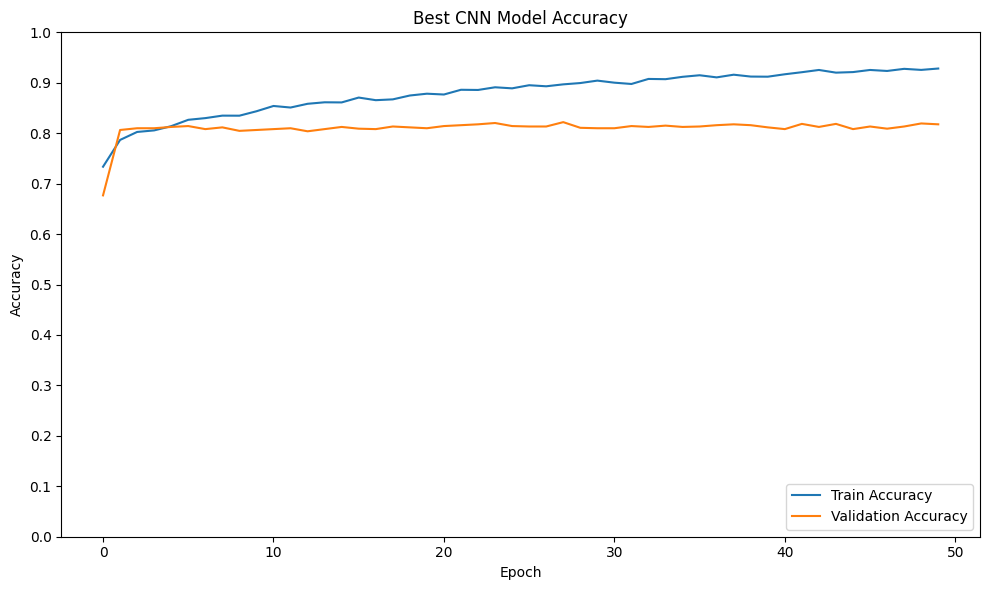

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))
plt.plot(history_1d.history['accuracy'], label='Train Accuracy')
plt.plot(history_1d.history['val_accuracy'], label='Validation Accuracy')
plt.title('Best CNN Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.yticks([i / 10 for i in range(11)])
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/CSNLP/Football/cnn_accuracy_plot.png")
plt.show()

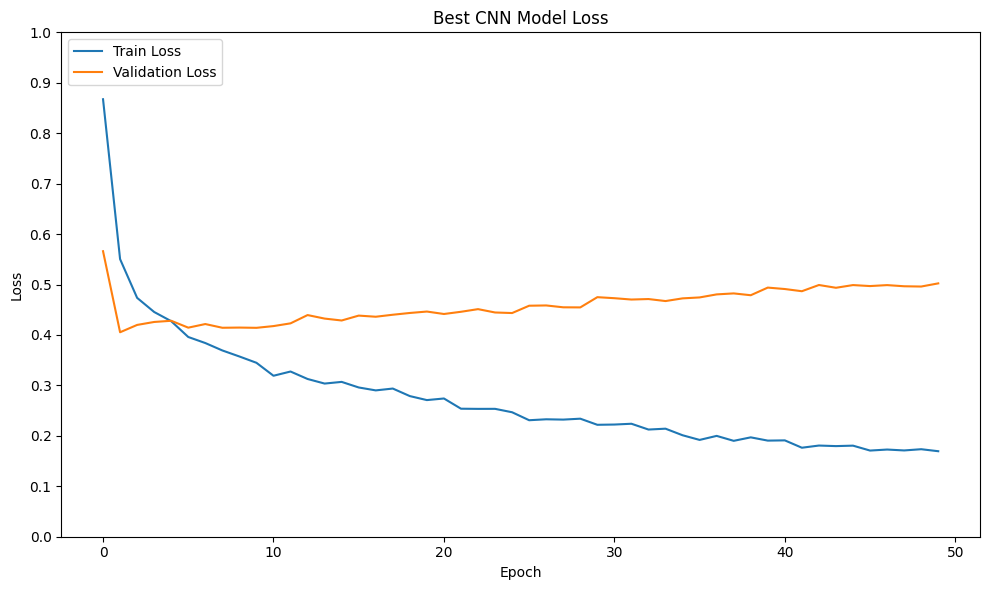

In [ ]:
# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history_1d.history['loss'], label='Train Loss')
plt.plot(history_1d.history['val_loss'], label='Validation Loss')
plt.title('Best CNN Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.yticks([i / 10 for i in range(11)])
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/CSNLP/Football/cnn_loss_curve.png")
plt.show()

In [ ]:
y_pred_train_cnn = model1d.predict(X_train_1d)
y_predict_cnn_model1d_eval_train = np.argmax(y_pred_train_cnn, axis=1)

# Compute confusion matrix
cm_cnn_model1d_eval_train = confusion_matrix(y_train, y_predict_cnn_model1d_eval_train)
print(cm_cnn_model1d_eval_train)

253/253 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
[[3177  183]
 [ 124 4612]]


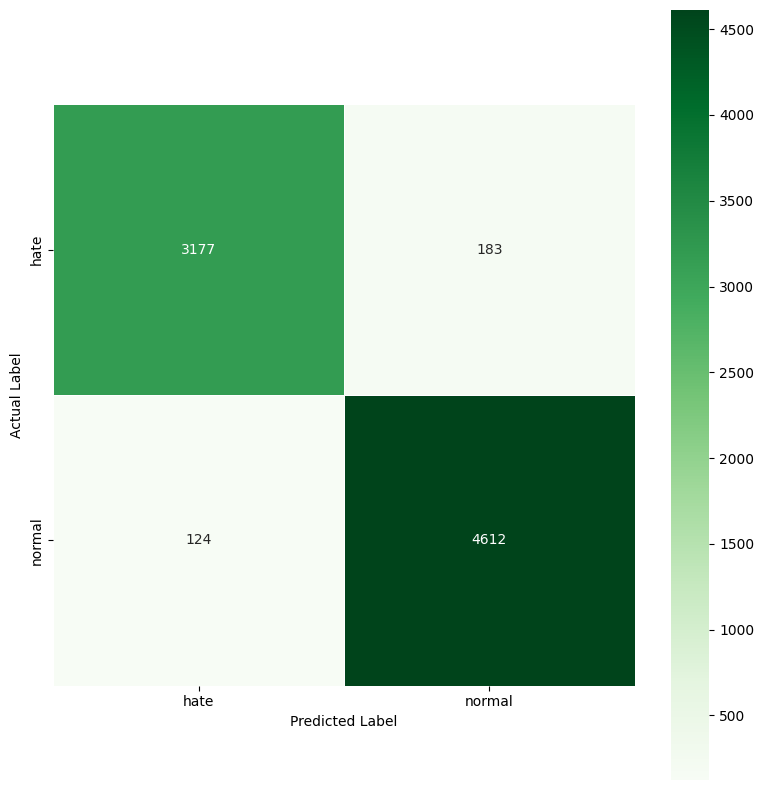

In [ ]:
plt.figure(figsize = (8,8))
sns.heatmap(cm_cnn_model1d_eval_train, annot=True, fmt='d', linewidth = .5, square = True, cmap = "Greens",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CSNLP/Football/cnn_model1d_eval_train_confusion_matrix.png')
plt.show()

In [ ]:
print(classification_report(y_train, y_predict_cnn_model1d_eval_train, target_names=le.classes_))

              precision    recall  f1-score   support

        hate       0.96      0.95      0.95      3360
      normal       0.96      0.97      0.97      4736

    accuracy                           0.96      8096
   macro avg       0.96      0.96      0.96      8096
weighted avg       0.96      0.96      0.96      8096



In [ ]:
print(classification_report(y_train, y_predict_cnn_model1d_eval_train, target_names=le.classes_))

              precision    recall  f1-score   support

        hate       0.96      0.95      0.95      3360
      normal       0.96      0.97      0.97      4736

    accuracy                           0.96      8096
   macro avg       0.96      0.96      0.96      8096
weighted avg       0.96      0.96      0.96      8096



In [ ]:
y_pred_cnn = model1d.predict(X_test_1d)
y_predict_cnn = np.argmax(y_pred_cnn, axis=1)

cm_cnn = confusion_matrix(y_test, y_predict_cnn)
print(cm_cnn)

73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
[[ 735  225]
 [ 221 1133]]


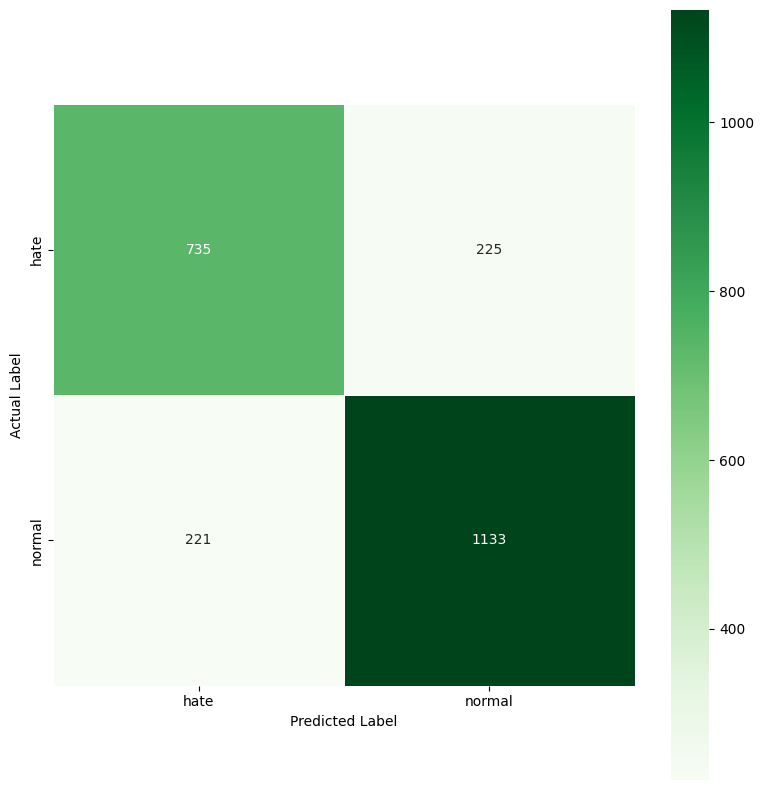

In [ ]:
plt.figure(figsize = (8,8))
sns.heatmap(cm_cnn, annot=True, fmt='d', linewidth = .5, square = True, cmap = "Greens",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/CSNLP/Football/cnn_model1d_eval_test_confusion_matrix.png')
plt.show()

In [ ]:
print(classification_report(y_test, y_predict_cnn, target_names=le.classes_))

              precision    recall  f1-score   support

        hate       0.77      0.77      0.77       960
      normal       0.83      0.84      0.84      1354

    accuracy                           0.81      2314
   macro avg       0.80      0.80      0.80      2314
weighted avg       0.81      0.81      0.81      2314



In [ ]:
print(classification_report(y_test, y_predict_cnn, target_names=le.classes_))

              precision    recall  f1-score   support

        hate       0.77      0.77      0.77       960
      normal       0.83      0.84      0.84      1354

    accuracy                           0.81      2314
   macro avg       0.80      0.80      0.80      2314
weighted avg       0.81      0.81      0.81      2314



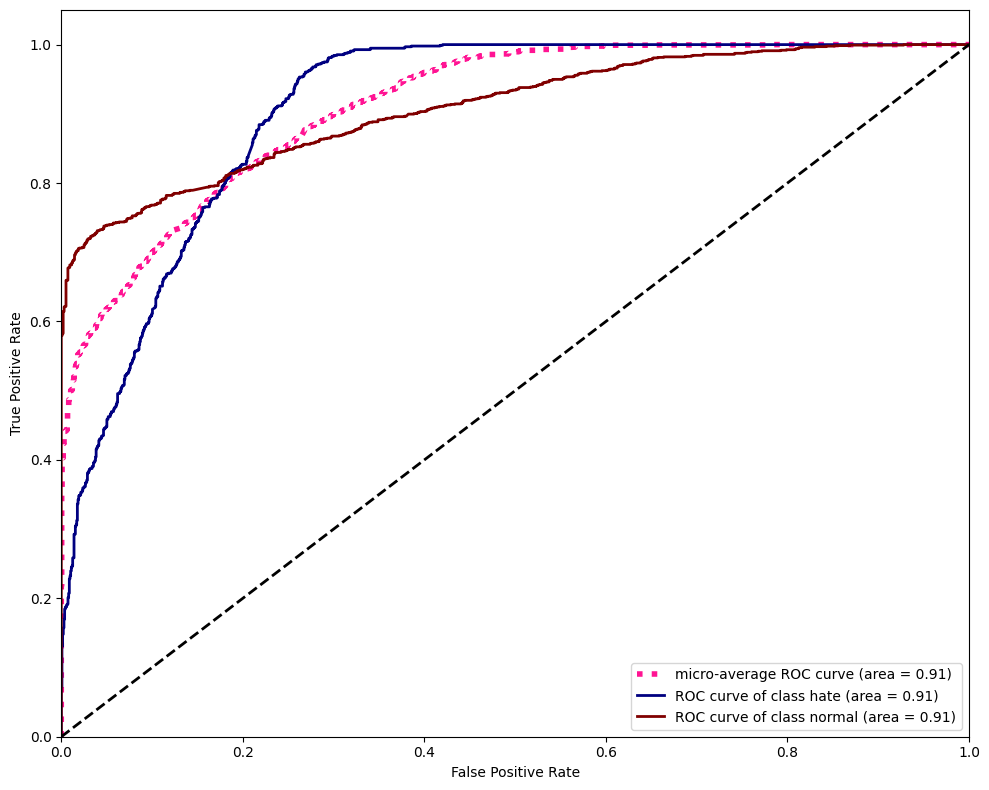

In [ ]:
# Get the number of classes
n_classes = len(le.classes_)

# Convert y_test to one-hot encoding
y_test_one_hot = to_categorical(y_test, num_classes=n_classes)

# Compute ROC curve and ROC area for each class
fpr_cnn_model1d_eval = dict()
tpr_cnn_model1d_eval = dict()
roc_auc_cnn_model1d_eval = dict()
for i in range(n_classes):
    fpr_cnn_model1d_eval[i], tpr_cnn_model1d_eval[i], _ = roc_curve(y_test_one_hot[:, i], y_pred_cnn[:, i])
    roc_auc_cnn_model1d_eval[i] = auc(fpr_cnn_model1d_eval[i], tpr_cnn_model1d_eval[i])

# Compute micro-average ROC curve and ROC area
fpr_micro_cnn_model1d_eval, tpr_micro_cnn_model1d_eval, _ = roc_curve(y_test_one_hot.ravel(), y_pred_cnn.ravel())
roc_auc_micro_cnn_model1d_eval = auc(fpr_micro_cnn_model1d_eval, tpr_micro_cnn_model1d_eval)

# Plot all ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_micro_cnn_model1d_eval, tpr_micro_cnn_model1d_eval,
         label='micro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc_micro_cnn_model1d_eval),
         color='deeppink', linestyle=':', linewidth=4)

colors = plt.cm.get_cmap('jet', n_classes)
for i, color in zip(range(n_classes), colors(np.linspace(0, 1, n_classes))):
    plt.plot(fpr_cnn_model1d_eval[i], tpr_cnn_model1d_eval[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
                   ''.format(le.classes_[i], roc_auc_cnn_model1d_eval[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CSNLP/Football/cnn_roc.png')
plt.show()

In [ ]:
model1d.save('/content/drive/MyDrive/CSNLP/Football/cnn_model1d.keras')

**LSTM**

In [ ]:
X_train_lstm = X_train.toarray().reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_lstm = X_test.toarray().reshape(X_test.shape[0], 1, X_test.shape[1])
X_val_lstm = X_val.toarray().reshape(X_val.shape[0], 1, X_val.shape[1])

In [ ]:
from keras.models import Sequential
from keras.layers import LSTM, BatchNormalization, Dropout, Dense

model_lstm = Sequential()

model_lstm.add(LSTM(units=256, input_shape=(1, X_train.shape[1])))
model_lstm.add(BatchNormalization())
model_lstm.add(Dropout(0.5))

model_lstm.add(Dense(100, activation='elu'))
model_lstm.add(BatchNormalization())
model_lstm.add(Dropout(0.3))

model_lstm.add(Dense(50, activation = 'elu'))
model_lstm.add(Dropout(0.3))


model_lstm.add(Dense(len(le.classes_), activation='softmax'))

In [ ]:
model_lstm.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_lstm.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 256)            │     1,953,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        25,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,986,068 (7.58 MB)

 Trainable params: 1,985,356 (7.57 MB)

 Non-trainable params: 712 (2.78 KB)

In [ ]:
history_lstm = model_lstm.fit(X_train_lstm, y_train, epochs=50, batch_size=32, validation_data=(X_val_lstm, y_val))

Epoch 1/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.7637 - loss: 0.5372 - val_accuracy: 0.6041 - val_loss: 0.5716
Epoch 2/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8261 - loss: 0.3711 - val_accuracy: 0.8124 - val_loss: 0.3830
Epoch 3/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8504 - loss: 0.3257 - val_accuracy: 0.8315 - val_loss: 0.3395
Epoch 4/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8597 - loss: 0.3049 - val_accuracy: 0.8332 - val_loss: 0.3442
Epoch 5/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8651 - loss: 0.2849 - val_accuracy: 0.8375 - val_loss: 0.3480
Epoch 6/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8682 - loss: 0.2735 - val_accuracy: 0.8392 - val_loss: 0.3485
Epoch 7/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8787 - loss: 0.2611 - val_accuracy: 0.8280 - val_loss: 0.3711
Epoch 8/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8791 - loss: 0.2502 - val_accuracy:

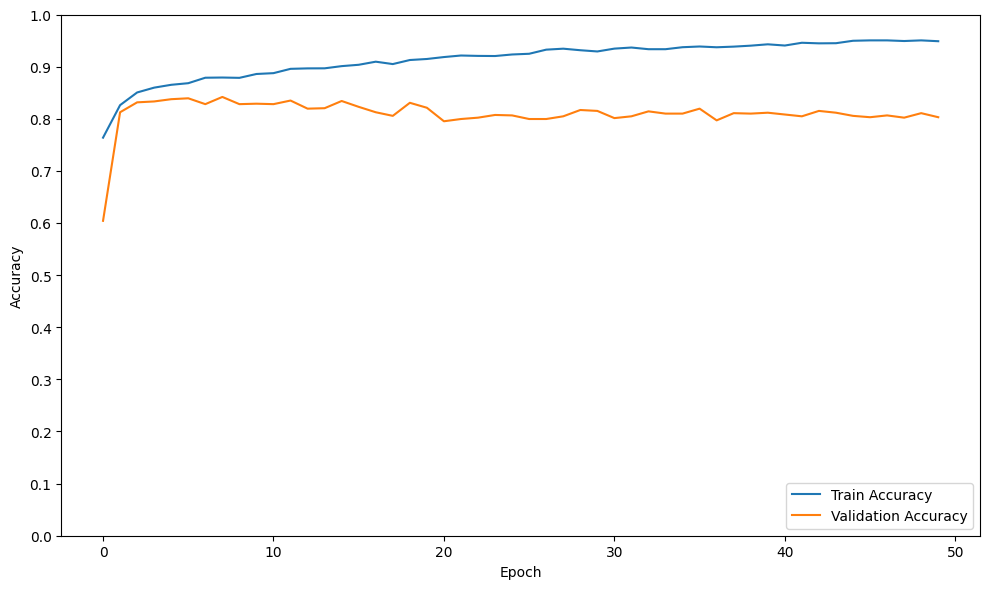

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))
plt.plot(history_lstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.yticks([i / 10 for i in range(11)])
plt.legend(loc='lower right')
plt.tight_layout()


plt.savefig('/content/drive/MyDrive/CSNLP/Football/lstm_accuracy.png')
plt.show()

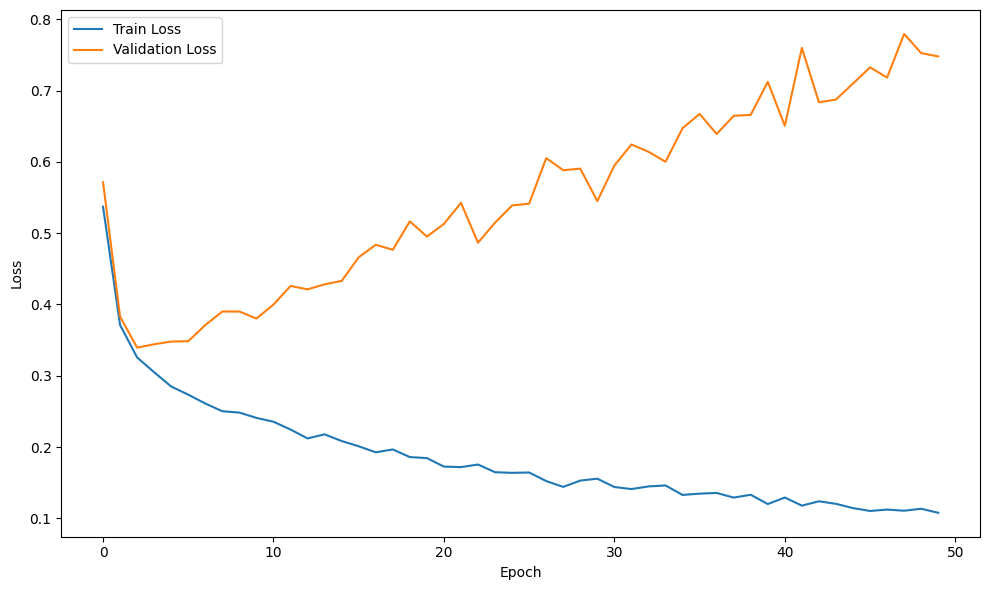

In [ ]:
# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/CSNLP/Football/lstm_loss.png')
plt.show()

In [ ]:
y_pred_probs_train_best_lstm = model_lstm.predict(X_train_lstm)
y_predict_best_lstm_train = np.argmax(y_pred_probs_train_best_lstm, axis=1)

cm_best_lstm_train = confusion_matrix(y_train, y_predict_best_lstm_train)
print(cm_best_lstm_train)

253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[[3227  133]
 [  87 4649]]


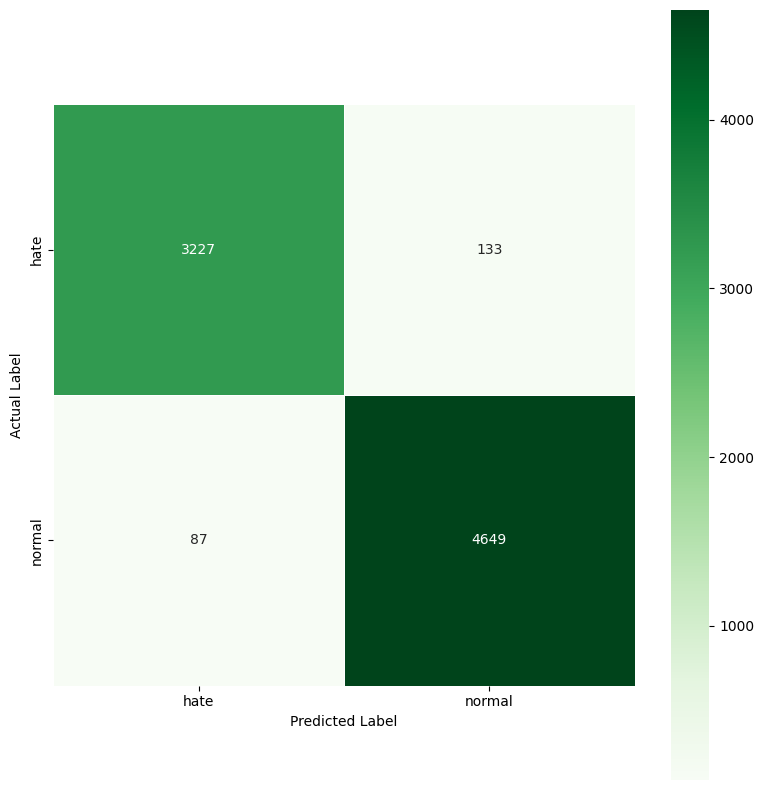

In [ ]:
plt.figure(figsize = (8,8))
sns.heatmap(cm_best_lstm_train, annot=True, fmt='d', linewidth = .5, square = True, cmap = "Greens",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/CSNLP/Football/lstm_train_confusion_matrix.png')
plt.show()

In [ ]:
lstm_train = classification_report(y_train, y_predict_best_lstm_train, target_names=le.classes_)
print("Best LSTM Train Report:\n", lstm_train)

Best LSTM Train Report:
               precision    recall  f1-score   support

        hate       0.97      0.96      0.97      3360
      normal       0.97      0.98      0.98      4736

    accuracy                           0.97      8096
   macro avg       0.97      0.97      0.97      8096
weighted avg       0.97      0.97      0.97      8096



In [ ]:
lstm_train = classification_report(y_train, y_predict_best_lstm_train, target_names=le.classes_)
print("Best LSTM Train Report:\n", lstm_train)

Best LSTM Train Report:
               precision    recall  f1-score   support

        hate       0.97      0.96      0.97      3360
      normal       0.97      0.98      0.98      4736

    accuracy                           0.97      8096
   macro avg       0.97      0.97      0.97      8096
weighted avg       0.97      0.97      0.97      8096



In [ ]:
y_pred_probs_test_best_lstm = model_lstm.predict(X_test_lstm)
y_predict_best_lstm_test = np.argmax(y_pred_probs_test_best_lstm, axis=1)

cm_best_lstm_test = confusion_matrix(y_test, y_predict_best_lstm_test)
print(cm_best_lstm_test)

73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
[[ 717  243]
 [ 219 1135]]


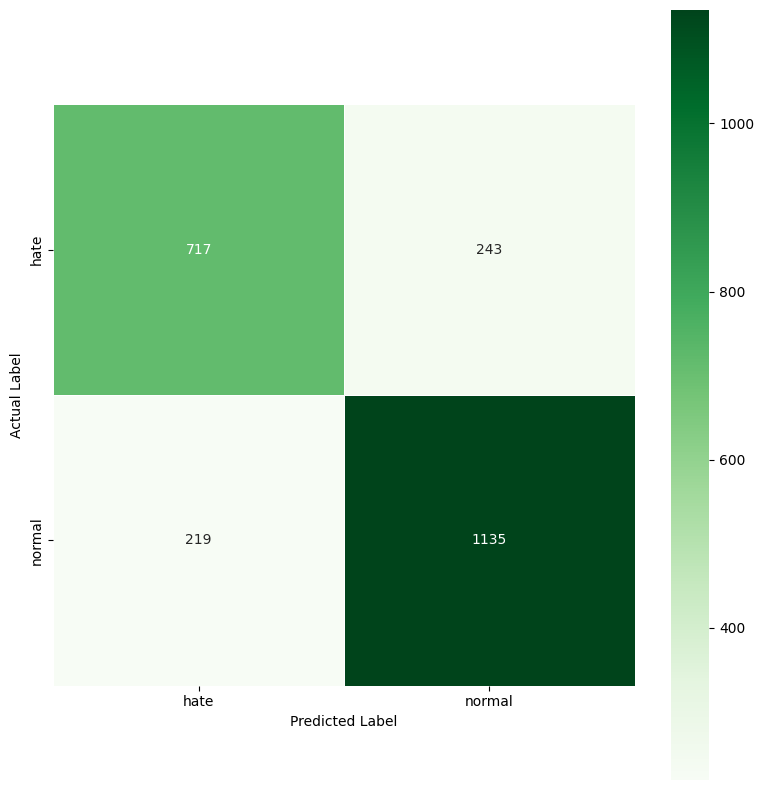

In [ ]:
plt.figure(figsize = (8,8))
sns.heatmap(cm_best_lstm_test, annot=True, fmt='d', linewidth = .5, square = True, cmap = "Greens",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/CSNLP/Football/lstm_test_confusion_matrix.png')
plt.show()

In [ ]:
report_best_lstm_test = classification_report(y_test, y_predict_best_lstm_test, target_names=le.classes_)
print("Best LSTM Test Report:\n", report_best_lstm_test)

Best LSTM Test Report:
               precision    recall  f1-score   support

        hate       0.77      0.75      0.76       960
      normal       0.82      0.84      0.83      1354

    accuracy                           0.80      2314
   macro avg       0.79      0.79      0.79      2314
weighted avg       0.80      0.80      0.80      2314



In [ ]:
report_best_lstm_test = classification_report(y_test, y_predict_best_lstm_test, target_names=le.classes_)
print("Best LSTM Test Report:\n", report_best_lstm_test)

Best LSTM Test Report:
               precision    recall  f1-score   support

        hate       0.77      0.75      0.76       960
      normal       0.82      0.84      0.83      1354

    accuracy                           0.80      2314
   macro avg       0.79      0.79      0.79      2314
weighted avg       0.80      0.80      0.80      2314



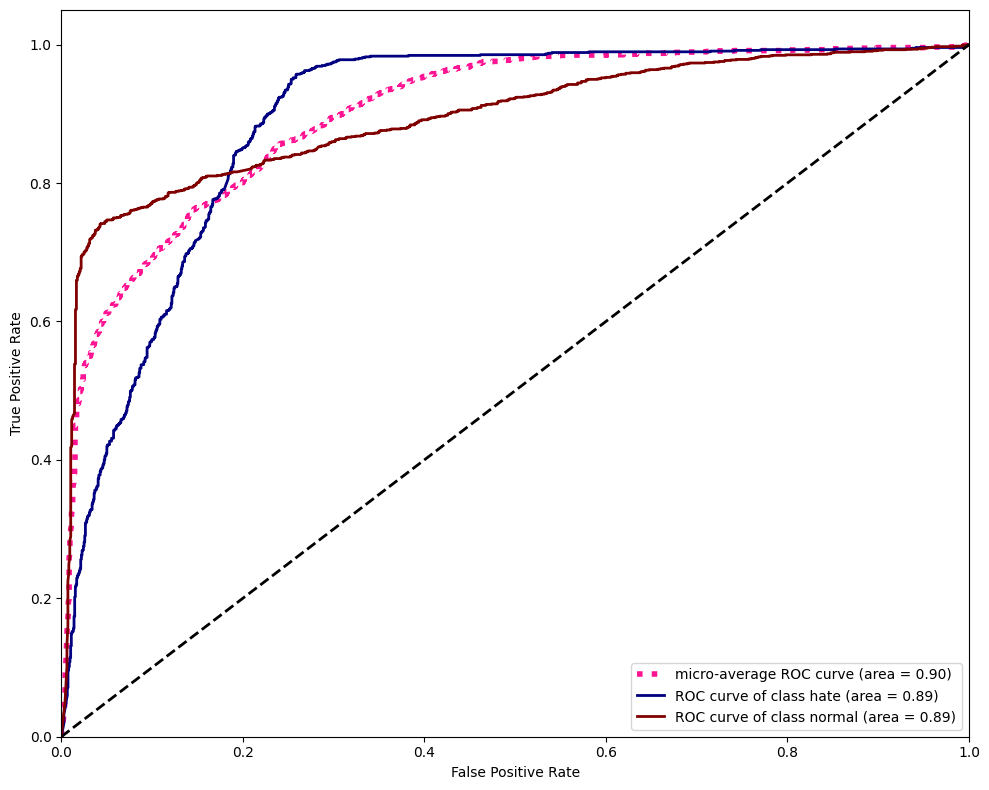

In [ ]:
# Get the number of classes
n_classes = len(le.classes_)

# Convert y_test to one-hot encoding
y_test_one_hot = to_categorical(y_test, num_classes=n_classes)

# Compute ROC curve and ROC area for each class
fpr_best_lstm = dict()
tpr_best_lstm = dict()
roc_auc_best_lstm = dict()
for i in range(n_classes):
    fpr_best_lstm[i], tpr_best_lstm[i], _ = roc_curve(y_test_one_hot[:, i], y_pred_probs_test_best_lstm[:, i])
    roc_auc_best_lstm[i] = auc(fpr_best_lstm[i], tpr_best_lstm[i])

# Compute micro-average ROC curve and ROC area
fpr_micro_best_lstm, tpr_micro_best_lstm, _ = roc_curve(y_test_one_hot.ravel(), y_pred_probs_test_best_lstm.ravel())
roc_auc_micro_best_lstm = auc(fpr_micro_best_lstm, tpr_micro_best_lstm)

# Plot all ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_micro_best_lstm, tpr_micro_best_lstm,
         label='micro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc_micro_best_lstm),
         color='deeppink', linestyle=':', linewidth=4)

colors = plt.cm.get_cmap('jet', n_classes)
for i, color in zip(range(n_classes), colors(np.linspace(0, 1, n_classes))):
    plt.plot(fpr_best_lstm[i], tpr_best_lstm[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
                   ''.format(le.classes_[i], roc_auc_best_lstm[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/CSNLP/Football/lstm_roc.png')
plt.show()

In [ ]:
model_lstm.save('/content/drive/MyDrive/CSNLP/Football/lstm.keras')

**GRU**

In [ ]:
X_train_gru = X_train.toarray().reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_gru = X_test.toarray().reshape(X_test.shape[0], 1, X_test.shape[1])
X_val_gru = X_val.toarray().reshape(X_val.shape[0], 1, X_val.shape[1])

In [ ]:
model_gru = Sequential()

model_gru.add(GRU(units=256, input_shape=(1, X_train.shape[1])))
model_gru.add(BatchNormalization())
model_gru.add(Dropout(0.5))

model_gru.add(Dense(100, activation='elu'))
model_gru.add(BatchNormalization())
model_gru.add(Dropout(0.3))

model_gru.add(Dense(50, activation = 'elu'))
model_gru.add(Dropout(0.3))

model_gru.add(Dense(len(le.classes_), activation='softmax'))

In [ ]:
model_gru.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_gru.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 256)            │     1,466,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 100)            │        25,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 2)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,498,388 (5.72 MB)

 Trainable params: 1,497,676 (5.71 MB)

 Non-trainable params: 712 (2.78 KB)

In [ ]:
history_gru = model_gru.fit(X_train_gru, y_train, epochs= 50, batch_size= 32, validation_data=(X_val_gru, y_val))

Epoch 1/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7517 - loss: 0.6021 - val_accuracy: 0.6491 - val_loss: 0.5299
Epoch 2/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8151 - loss: 0.3967 - val_accuracy: 0.8194 - val_loss: 0.3795
Epoch 3/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8431 - loss: 0.3393 - val_accuracy: 0.8315 - val_loss: 0.3402
Epoch 4/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8582 - loss: 0.3120 - val_accuracy: 0.8289 - val_loss: 0.3418
Epoch 5/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8686 - loss: 0.2883 - val_accuracy: 0.8280 - val_loss: 0.3532
Epoch 6/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8687 - loss: 0.2795 - val_accuracy: 0.8341 - val_loss: 0.3553
Epoch 7/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8727 - loss: 0.2715 - val_accuracy: 0.8315 - val_loss: 0.3586
Epoch 8/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8840 - loss: 0.2549 - val_accuracy: 

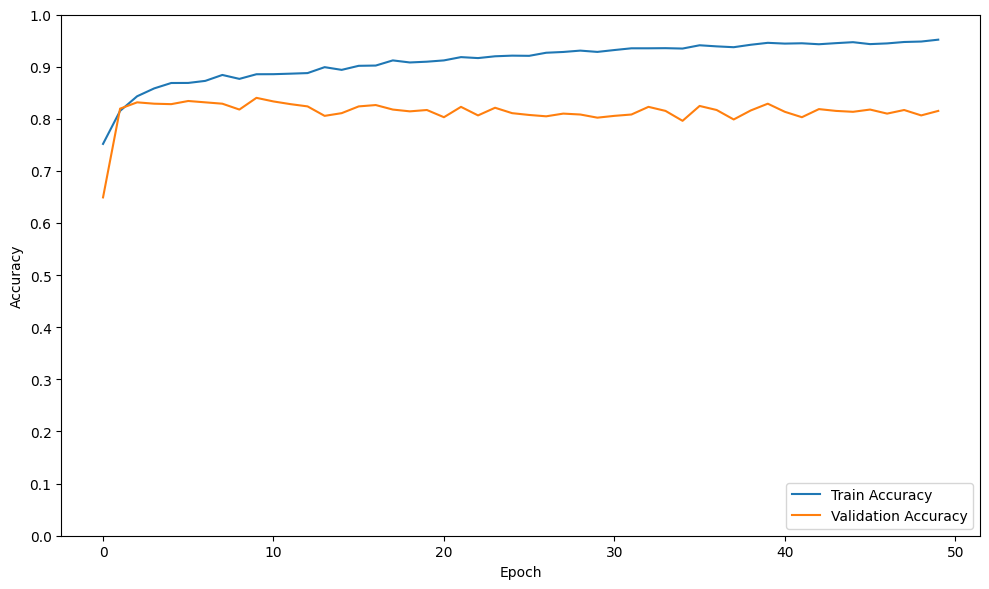

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))
plt.plot(history_gru.history['accuracy'], label='Train Accuracy')
plt.plot(history_gru.history['val_accuracy'], label='Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.yticks([i / 10 for i in range(11)])
plt.legend(loc='lower right')
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/CSNLP/Football/gru_accuracy.png')
plt.show()

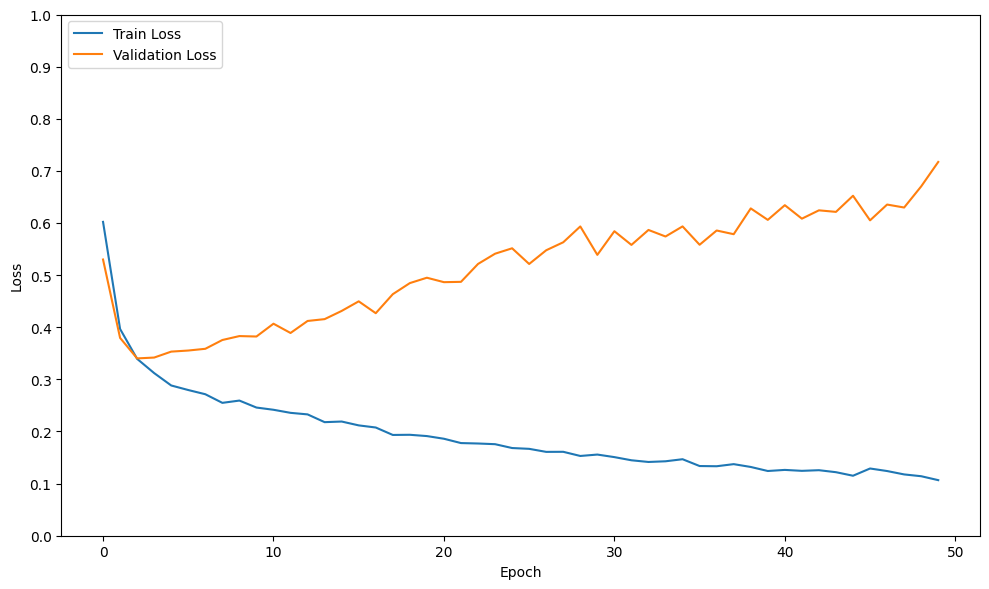

In [ ]:
# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history_gru.history['loss'], label='Train Loss')
plt.plot(history_gru.history['val_loss'], label='Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.yticks([i / 10 for i in range(11)])
plt.legend(loc='upper left')
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/CSNLP/Football/gru_loss.png')
plt.show()

In [ ]:
y_pred_probs_train_gru = model_gru.predict(X_train_gru)
y_predict_gru_train = np.argmax(y_pred_probs_train_gru, axis=1)

# Compute confusion matrix
cm_gru_train = confusion_matrix(y_train, y_predict_gru_train)
print(cm_gru_train)

253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[[3218  142]
 [  75 4661]]


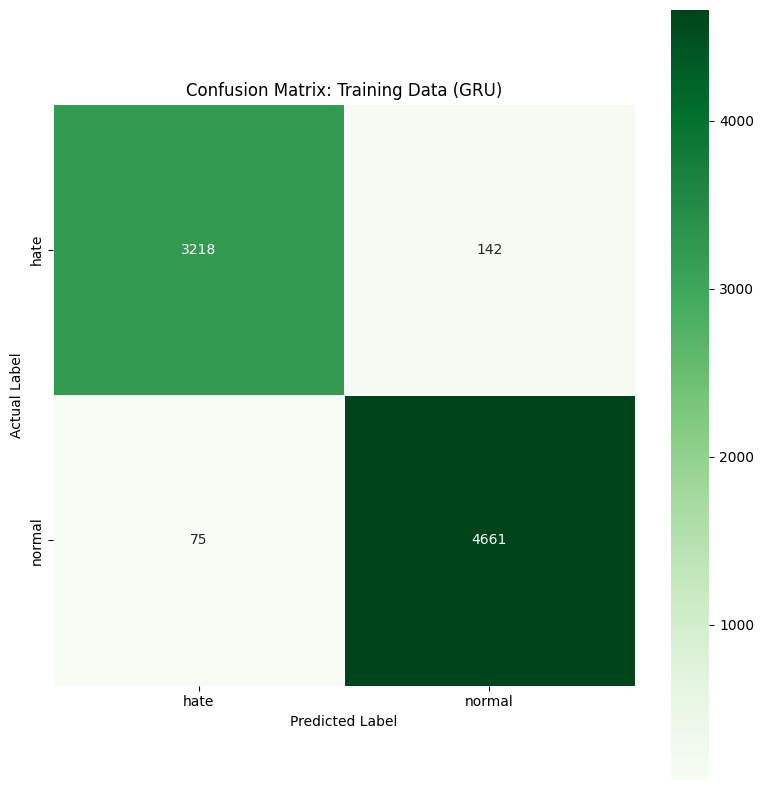

In [ ]:
plt.figure(figsize = (8,8))
sns.heatmap(cm_gru_train, annot=True, fmt='d', linewidth = .5, square = True, cmap = "Greens",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: Training Data (GRU)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/CSNLP/Football/gru_train_confusion_matrix.png')
plt.show()

In [ ]:
report_gru_train = classification_report(y_train, y_predict_gru_train, target_names=le.classes_)
print("GRU Train Report:\n", report_gru_train)

GRU Train Report:
               precision    recall  f1-score   support

        hate       0.98      0.96      0.97      3360
      normal       0.97      0.98      0.98      4736

    accuracy                           0.97      8096
   macro avg       0.97      0.97      0.97      8096
weighted avg       0.97      0.97      0.97      8096



In [ ]:
report_gru_train = classification_report(y_train, y_predict_gru_train, target_names=le.classes_)
print("GRU Train Report:\n", report_gru_train)

GRU Train Report:
               precision    recall  f1-score   support

        hate       0.98      0.96      0.97      3360
      normal       0.97      0.98      0.98      4736

    accuracy                           0.97      8096
   macro avg       0.97      0.97      0.97      8096
weighted avg       0.97      0.97      0.97      8096



In [ ]:
y_pred_probs_test_gru = model_gru.predict(X_test_gru)
y_predict_gru_test = np.argmax(y_pred_probs_test_gru, axis=1)

cm_gru_test = confusion_matrix(y_test, y_predict_gru_test)
print(cm_gru_test)

73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
[[ 716  244]
 [ 223 1131]]


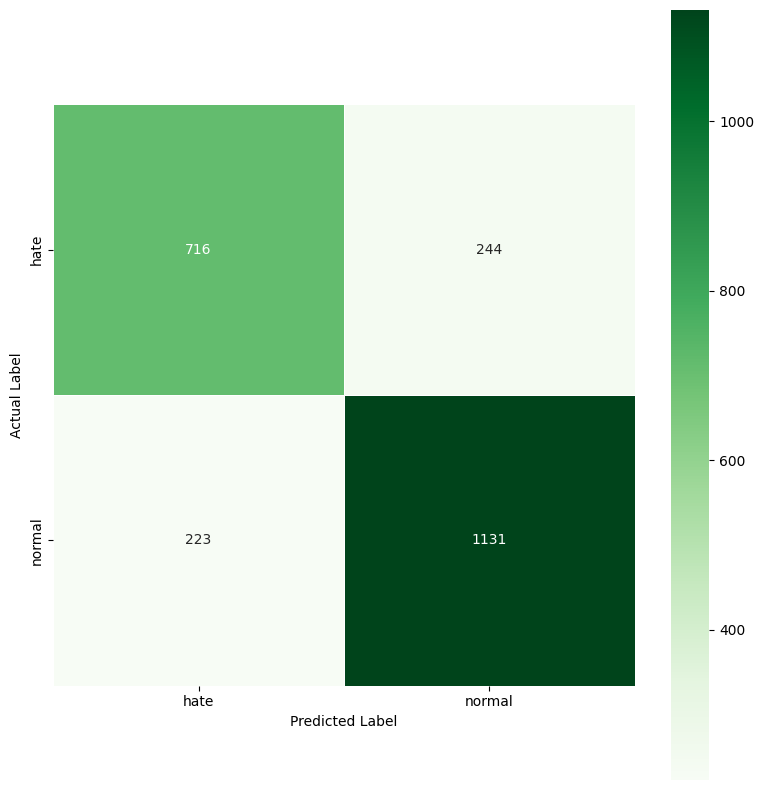

In [ ]:
plt.figure(figsize = (8,8))
sns.heatmap(cm_gru_test, annot=True, fmt='d', linewidth = .5, square = True, cmap = "Greens",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/CSNLP/Football/gru_test_confusion_matrix.png')
plt.show()

In [ ]:
report_gru_test = classification_report(y_test, y_predict_gru_test, target_names=le.classes_)
print("GRU Test Report:\n", report_gru_test)

GRU Test Report:
               precision    recall  f1-score   support

        hate       0.76      0.75      0.75       960
      normal       0.82      0.84      0.83      1354

    accuracy                           0.80      2314
   macro avg       0.79      0.79      0.79      2314
weighted avg       0.80      0.80      0.80      2314



In [ ]:
report_gru_test = classification_report(y_test, y_predict_gru_test, target_names=le.classes_)
print("GRU Test Report:\n", report_gru_test)

GRU Test Report:
               precision    recall  f1-score   support

        hate       0.76      0.75      0.75       960
      normal       0.82      0.84      0.83      1354

    accuracy                           0.80      2314
   macro avg       0.79      0.79      0.79      2314
weighted avg       0.80      0.80      0.80      2314



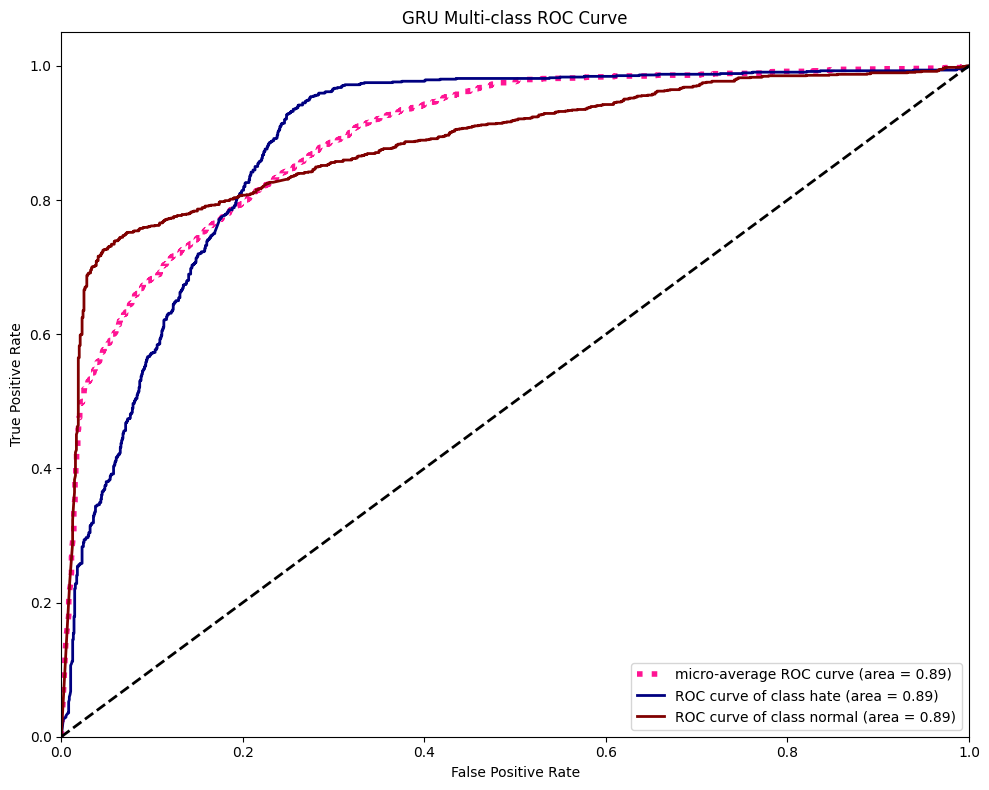

In [ ]:
# Get the number of classes
n_classes = len(le.classes_)

# Convert y_test to one-hot encoding
y_test_one_hot = to_categorical(y_test, num_classes=n_classes)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_one_hot[:, i], y_pred_probs_test_gru[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr_micro, tpr_micro, _ = roc_curve(y_test_one_hot.ravel(), y_pred_probs_test_gru.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

# Plot all ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_micro, tpr_micro,
         label='micro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc_micro),
         color='deeppink', linestyle=':', linewidth=4)

colors = plt.cm.get_cmap('jet', n_classes)
for i, color in zip(range(n_classes), colors(np.linspace(0, 1, n_classes))):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
                   ''.format(le.classes_[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('GRU Multi-class ROC Curve')
plt.legend(loc="lower right")
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/CSNLP/Football/gru_roc.png')
plt.show()

In [ ]:
model_gru.save('/content/drive/MyDrive/CSNLP/Football/gru.keras')

**CNN_LSTM**

In [20]:
X_train_cnn_lstm = X_train.toarray().reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn_lstm = X_test.toarray().reshape(X_test.shape[0], X_test.shape[1], 1)
X_val_cnn_lstm = X_val.toarray().reshape(X_val.shape[0], X_val.shape[1], 1)

In [24]:
model_cnn_lstm = Sequential()

model_cnn_lstm.add(Conv1D(filters=64, kernel_size=5, activation='elu', input_shape=(X_train.shape[1], 1)))
model_cnn_lstm.add(BatchNormalization())
model_cnn_lstm.add(MaxPooling1D(pool_size=2))
model_cnn_lstm.add(Dropout(0.3))

model_cnn_lstm.add(Conv1D(filters=128, kernel_size=3, activation='elu'))
model_cnn_lstm.add(BatchNormalization())
model_cnn_lstm.add(MaxPooling1D(pool_size=2))
model_cnn_lstm.add(Dropout(0.4))

model_cnn_lstm.add(Conv1D(filters=256, kernel_size=3, activation='elu'))
model_cnn_lstm.add(BatchNormalization())
model_cnn_lstm.add(MaxPooling1D(pool_size=2))
model_cnn_lstm.add(Dropout(0.4))

model_cnn_lstm.add(LSTM(units=128, return_sequences=True))
model_cnn_lstm.add(Dropout(0.3))
model_cnn_lstm.add(LSTM(units=128, return_sequences=False))
model_cnn_lstm.add(Dropout(0.3))

model_cnn_lstm.add(Flatten())

model_cnn_lstm.add(Dense(128, activation='elu'))
model_cnn_lstm.add(Dropout(0.3))


model_cnn_lstm.add(Dense(len(le.classes_), activation='softmax'))

In [25]:
model_cnn_lstm.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_cnn_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_5 (Conv1D)               │ (None, 1647, 64)       │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1647, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 823, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 823, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 821, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 821, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 410, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 410, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 408, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 408, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 204, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 204, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 204, 128)       │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 204, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 470,914 (1.80 MB)

 Trainable params: 470,018 (1.79 MB)

 Non-trainable params: 896 (3.50 KB)

In [26]:
history_cl = model_cnn_lstm.fit(X_train_cnn_lstm, y_train, epochs=50, batch_size=32, validation_data=(X_val_cnn_lstm, y_val))

Epoch 1/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.5912 - loss: 0.6570 - val_accuracy: 0.5575 - val_loss: 0.6859
Epoch 2/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.6334 - loss: 0.6213 - val_accuracy: 0.6474 - val_loss: 0.6041
Epoch 3/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.6519 - loss: 0.6009 - val_accuracy: 0.6249 - val_loss: 0.6561
Epoch 4/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.6624 - loss: 0.5914 - val_accuracy: 0.4892 - val_loss: 0.7116
Epoch 5/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.6748 - loss: 0.5838 - val_accuracy: 0.6845 - val_loss: 0.5879
Epoch 6/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.6819 - loss: 0.5743 - val_accuracy: 0.6309 - val_loss: 0.6207
Epoch 7/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.6823 - loss: 0.5680 - val_accuracy: 0.6335 - val_loss: 0.6946
Epoch 8/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.6928 - loss: 0.5552 - va

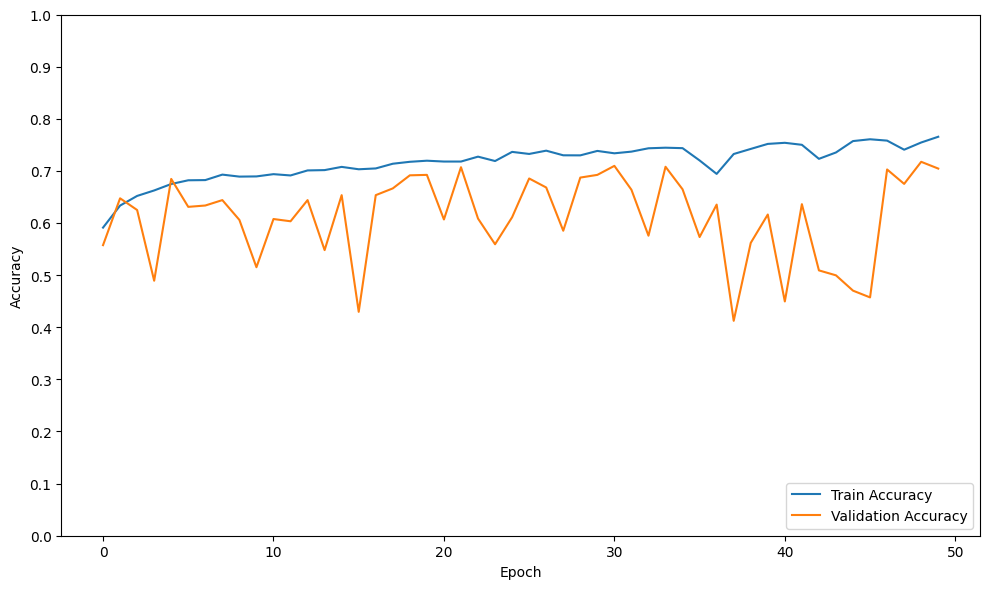

In [27]:
# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))
plt.plot(history_cl.history['accuracy'], label='Train Accuracy')
plt.plot(history_cl.history['val_accuracy'], label='Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.yticks([i / 10 for i in range(11)])
plt.legend(loc='lower right')
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/CSNLP/Football/cnn_lstm_accuracy.png')
plt.show()

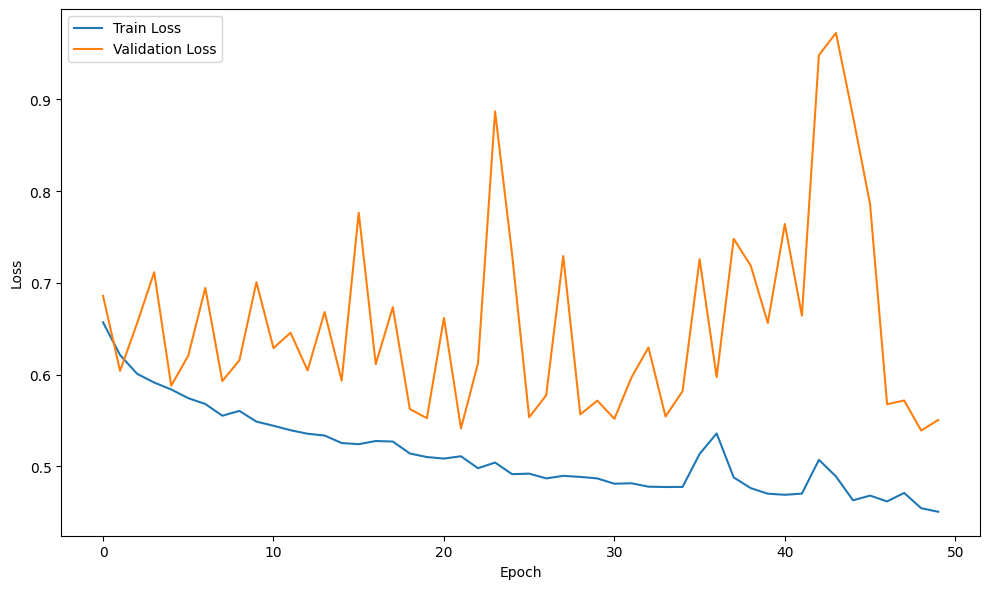

In [28]:
# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history_cl.history['loss'], label='Train Loss')
plt.plot(history_cl.history['val_loss'], label='Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/CSNLP/Football/cnn_lstm_loss.png')
plt.show()

In [29]:
y_pred_probs_train_best_cnn_lstm = model_cnn_lstm.predict(X_train_cnn_lstm)
y_predict_best_cl_train = np.argmax(y_pred_probs_train_best_cnn_lstm, axis=1)

cm_best_cl_train = confusion_matrix(y_train, y_predict_best_cl_train)
print(cm_best_cl_train)

253/253 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step
[[2730  630]
 [1360 3376]]


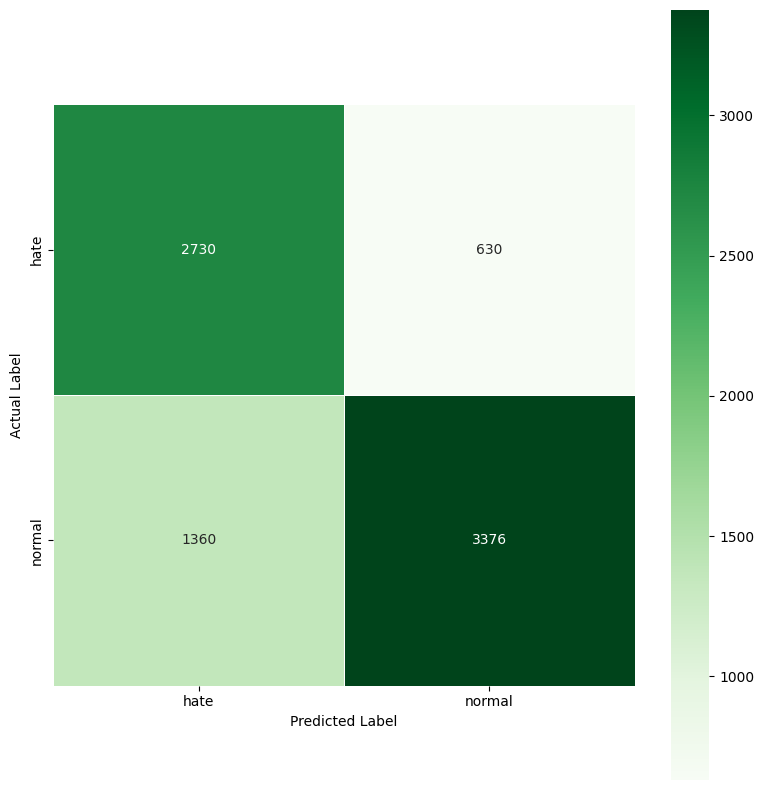

In [30]:
plt.figure(figsize = (8,8))
sns.heatmap(cm_best_cl_train, annot=True, fmt='d', linewidth = .5, square = True, cmap = "Greens",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/CSNLP/Football/cnn_lstm_train_confusion_matrix.png')
plt.show()

In [31]:
report_best_cnn_lstm_train = classification_report(y_train, y_predict_best_cl_train, target_names=le.classes_)
print("Best CNN-LSTM Train Report:\n", report_best_cnn_lstm_train)

Best CNN-LSTM Train Report:
               precision    recall  f1-score   support

        hate       0.67      0.81      0.73      3360
      normal       0.84      0.71      0.77      4736

    accuracy                           0.75      8096
   macro avg       0.76      0.76      0.75      8096
weighted avg       0.77      0.75      0.76      8096



In [ ]:
report_best_cnn_lstm_train = classification_report(y_train, y_predict_best_cl_train, target_names=le.classes_)
print("Best CNN-LSTM Train Report:\n", report_best_cnn_lstm_train)

Best CNN-LSTM Train Report:
               precision    recall  f1-score   support

        hate       0.53      0.57      0.55      3360
      normal       0.68      0.65      0.66      4736

    accuracy                           0.62      8096
   macro avg       0.61      0.61      0.61      8096
weighted avg       0.62      0.62      0.62      8096



In [32]:
y_pred_probs_test_best_cnn_lstm = model_cnn_lstm.predict(X_test_cnn_lstm)
y_predict_best_cl_test = np.argmax(y_pred_probs_test_best_cnn_lstm, axis=1)

cm_best_cl_test = confusion_matrix(y_test, y_predict_best_cl_test)
print(cm_best_cl_test)

73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step
[[728 232]
 [409 945]]


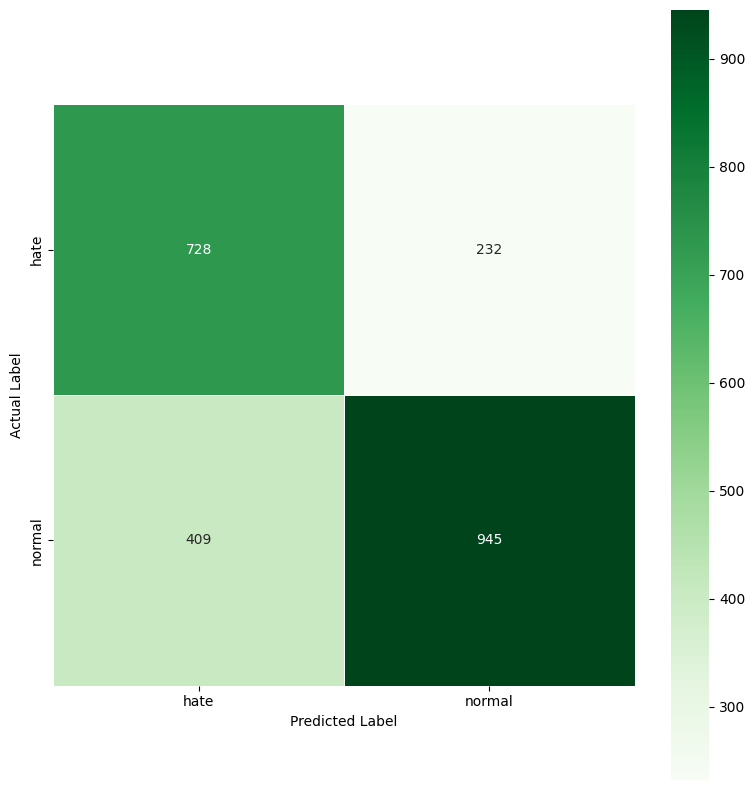

In [33]:
plt.figure(figsize = (8,8))
sns.heatmap(cm_best_cl_test, annot=True, fmt='d', linewidth = .5, square = True, cmap = "Greens",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/CSNLP/Football/cnn_lstm_test_confusion_matrix.png')
plt.show()

In [34]:
report_best_cnn_lstm_test = classification_report(y_test, y_predict_best_cl_test, target_names=le.classes_)
print("Best CNN-LSTM Test Report:\n", report_best_cnn_lstm_test)

Best CNN-LSTM Test Report:
               precision    recall  f1-score   support

        hate       0.64      0.76      0.69       960
      normal       0.80      0.70      0.75      1354

    accuracy                           0.72      2314
   macro avg       0.72      0.73      0.72      2314
weighted avg       0.74      0.72      0.72      2314



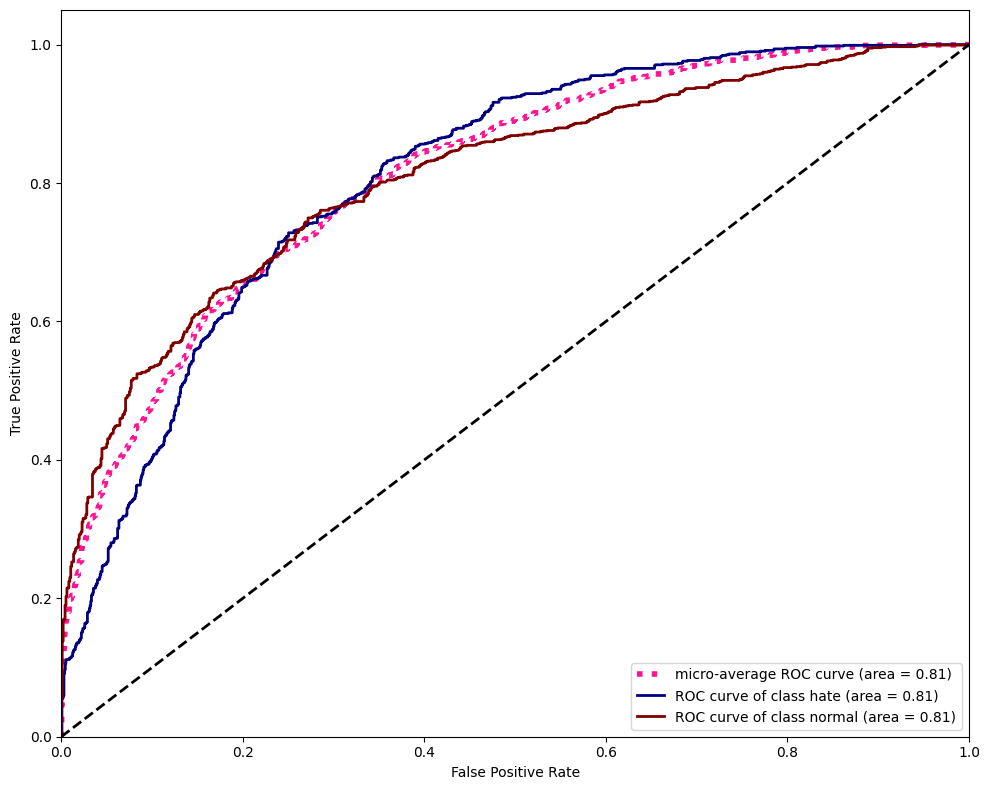

In [35]:
# Get the number of classes
n_classes = len(le.classes_)

# Convert y_test to one-hot encoding
y_test_one_hot = to_categorical(y_test, num_classes=n_classes)

# Compute ROC curve and ROC area for each class
fpr_best_cnn_lstm = dict()
tpr_best_cnn_lstm = dict()
roc_auc_best_cnn_lstm = dict()
for i in range(n_classes):
    fpr_best_cnn_lstm[i], tpr_best_cnn_lstm[i], _ = roc_curve(y_test_one_hot[:, i], y_pred_probs_test_best_cnn_lstm[:, i])
    roc_auc_best_cnn_lstm[i] = auc(fpr_best_cnn_lstm[i], tpr_best_cnn_lstm[i])

# Compute micro-average ROC curve and ROC area
fpr_micro_best_cnn_lstm, tpr_micro_best_cnn_lstm, _ = roc_curve(y_test_one_hot.ravel(), y_pred_probs_test_best_cnn_lstm.ravel())
roc_auc_micro_best_cnn_lstm = auc(fpr_micro_best_cnn_lstm, tpr_micro_best_cnn_lstm)

# Plot all ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_micro_best_cnn_lstm, tpr_micro_best_cnn_lstm,
         label='micro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc_micro_best_cnn_lstm),
         color='deeppink', linestyle=':', linewidth=4)

colors = plt.cm.get_cmap('jet', n_classes)
for i, color in zip(range(n_classes), colors(np.linspace(0, 1, n_classes))):
    plt.plot(fpr_best_cnn_lstm[i], tpr_best_cnn_lstm[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
                   ''.format(le.classes_[i], roc_auc_best_cnn_lstm[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/CSNLP/Football/cnn_lstm_roc.png')
plt.show()

In [36]:
model_cnn_lstm.save('/content/drive/MyDrive/CSNLP/Football/cnn_lstm.keras')

**CNN_GRU**

In [37]:
model_cg = Sequential()

model_cg.add(Conv1D(filters=64, kernel_size=5, activation='elu', input_shape=(X_train.shape[1], 1)))
model_cg.add(BatchNormalization())
model_cg.add(MaxPooling1D(pool_size=2))
model_cg.add(Dropout(0.3))

model_cg.add(Conv1D(filters=128, kernel_size=3, activation='elu'))
model_cg.add(BatchNormalization())
model_cg.add(MaxPooling1D(pool_size=2))
model_cg.add(Dropout(0.4))

model_cg.add(Conv1D(filters=256, kernel_size=3, activation='elu', kernel_regularizer=l2(0.01)))
model_cg.add(BatchNormalization())
model_cg.add(MaxPooling1D(pool_size=2))
model_cg.add(Dropout(0.4))

model_cg.add(GRU(units=128, return_sequences=True))
model_cg.add(BatchNormalization())
model_cg.add(Dropout(0.3))

model_cg.add(GRU(units=128, return_sequences=False))
model_cg.add(BatchNormalization())
model_cg.add(Dropout(0.3))

model_cg.add(Flatten())

model_cg.add(Dense(128, activation='elu', kernel_regularizer=l2(0.01)))
model_cg.add(Dropout(0.3))


model_cg.add(Dense(len(le.classes_), activation='softmax'))

In [38]:
model_cg.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_cg.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 1647, 64)       │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 1647, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 823, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 823, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 821, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 821, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 410, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 410, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 408, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 408, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 204, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 204, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 204, 128)       │       148,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 204, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 204, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 390,530 (1.49 MB)

 Trainable params: 389,122 (1.48 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [39]:
X_val_cnn_gru = X_val.toarray().reshape(X_val.shape[0], X_val.shape[1], 1)
history_cg = model_cg.fit(X_train_cnn_lstm, y_train, epochs=50, batch_size=32, validation_data=(X_val_cnn_gru, y_val))

Epoch 1/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.5356 - loss: 2.9349 - val_accuracy: 0.4417 - val_loss: 2.1290
Epoch 2/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.5755 - loss: 1.6593 - val_accuracy: 0.6007 - val_loss: 1.2583
Epoch 3/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.5770 - loss: 1.0816 - val_accuracy: 0.6024 - val_loss: 0.8983
Epoch 4/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.5851 - loss: 0.8427 - val_accuracy: 0.5990 - val_loss: 0.9518
Epoch 5/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.5919 - loss: 0.7622 - val_accuracy: 0.5601 - val_loss: 0.7816
Epoch 6/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.6427 - loss: 0.7156 - val_accuracy: 0.5990 - val_loss: 0.8644
Epoch 7/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - accuracy: 0.6575 - loss: 0.6996 - val_accuracy: 0.6145 - val_loss: 0.8085
Epoch 8/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.6632 - loss: 0.6843 - 

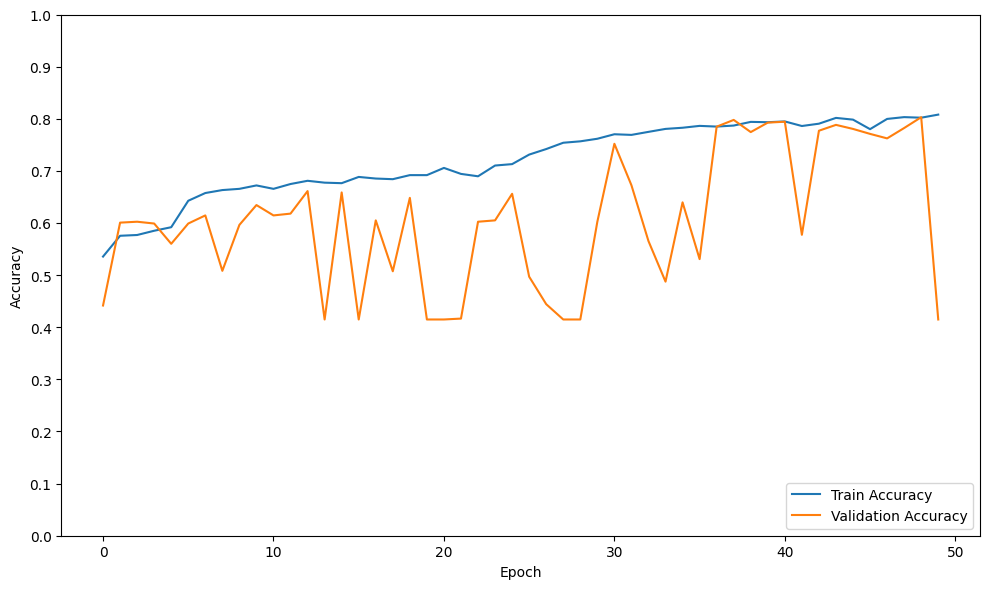

In [40]:
# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))
plt.plot(history_cg.history['accuracy'], label='Train Accuracy')
plt.plot(history_cg.history['val_accuracy'], label='Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.yticks([i / 10 for i in range(11)])
plt.legend(loc='lower right')
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/CSNLP/Football/cnn_gru_accuracy.png')
plt.show()

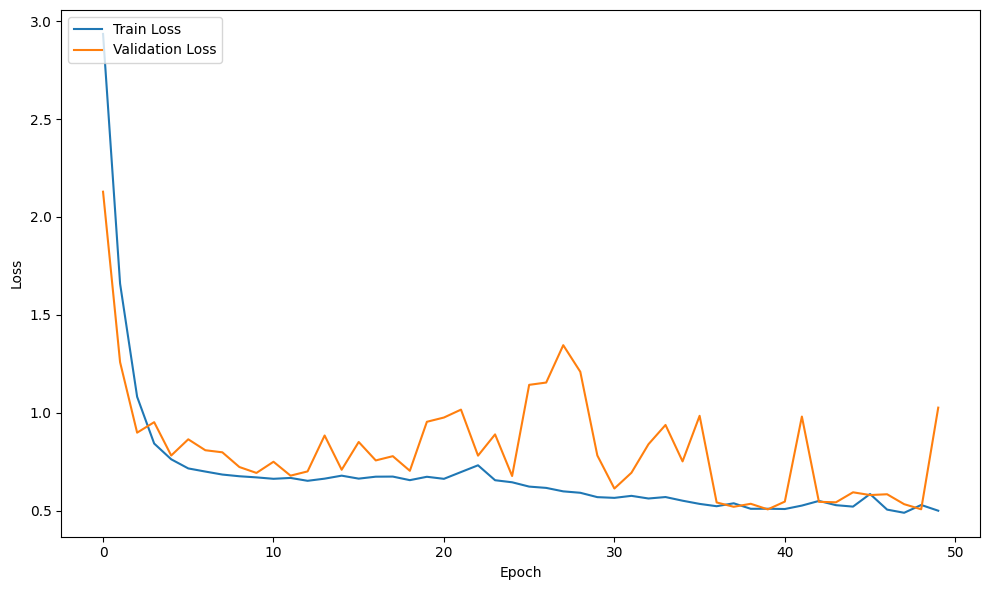

In [41]:
# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history_cg.history['loss'], label='Train Loss')
plt.plot(history_cg.history['val_loss'], label='Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/CSNLP/Football/cnn_gru_loss.png')
plt.show()

In [42]:
y_pred_probs_train_best_cg = model_cg.predict(X_train_cnn_lstm)
y_predict_best_cg_train = np.argmax(y_pred_probs_train_best_cg, axis=1)


cm_best_cg_train = confusion_matrix(y_train, y_predict_best_cg_train)
print(cm_best_cg_train)

253/253 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step
[[3360    0]
 [4736    0]]


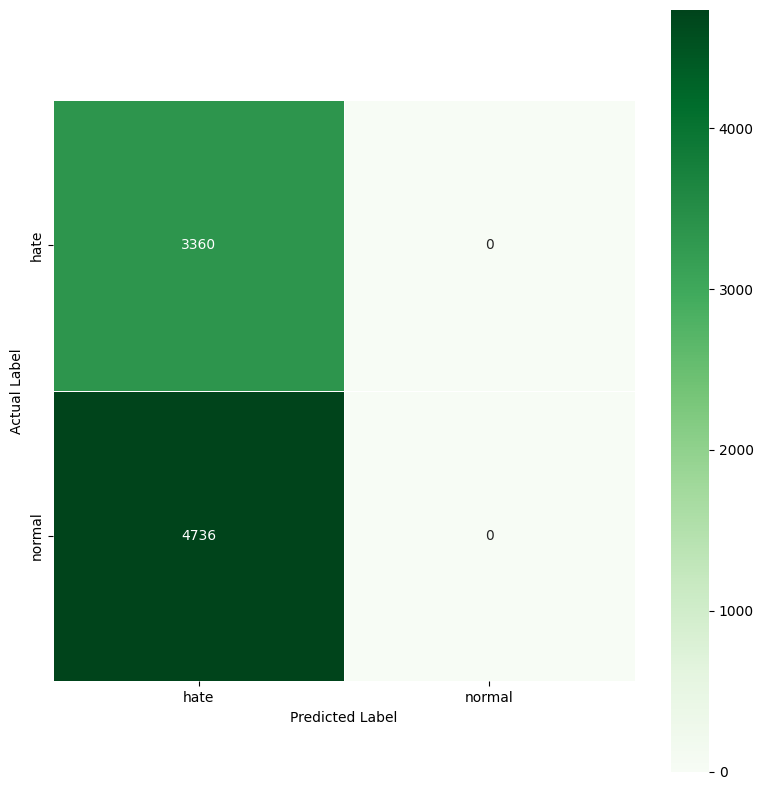

In [43]:
plt.figure(figsize = (8,8))
sns.heatmap(cm_best_cg_train, annot=True, fmt='d', linewidth = .5, square = True, cmap = "Greens",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/CSNLP/Football/cnn_gru_train_confusion_matrix.png')
plt.show()

In [44]:
report_best_cg_train = classification_report(y_train, y_predict_best_cg_train, target_names=le.classes_)
print("Best CNN-GRU Train Report:\n", report_best_cg_train)

Best CNN-GRU Train Report:
               precision    recall  f1-score   support

        hate       0.42      1.00      0.59      3360
      normal       0.00      0.00      0.00      4736

    accuracy                           0.42      8096
   macro avg       0.21      0.50      0.29      8096
weighted avg       0.17      0.42      0.24      8096



In [45]:
y_pred_probs_test_best_cg = model_cg.predict(X_test_cnn_lstm)
y_predict_best_cg_test = np.argmax(y_pred_probs_test_best_cg, axis=1)

cm_best_cg_test = confusion_matrix(y_test, y_predict_best_cg_test)
print(cm_best_cg_test)

73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
[[ 960    0]
 [1354    0]]


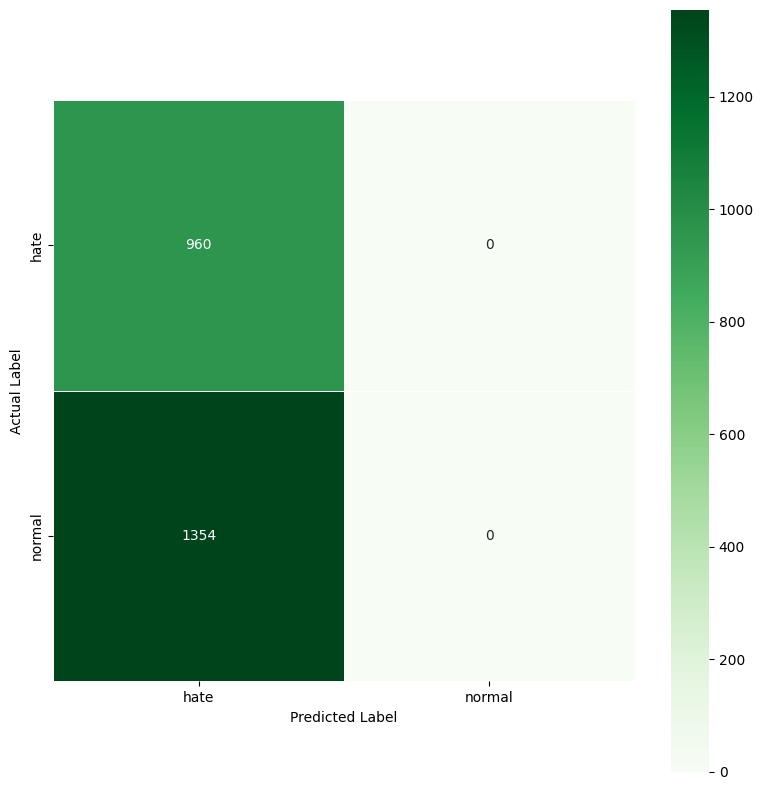

In [46]:
plt.figure(figsize = (8,8))
sns.heatmap(cm_best_cg_test, annot=True, fmt='d', linewidth = .5, square = True, cmap = "Greens",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/CSNLP/Football/cnn_gru_test_confusion_matrix.png')
plt.show()

In [47]:
report_best_cg_test = classification_report(y_test, y_predict_best_cg_test, target_names=le.classes_)
print("Best CNN-GRU Test Report:\n", report_best_cg_test)

Best CNN-GRU Test Report:
               precision    recall  f1-score   support

        hate       0.41      1.00      0.59       960
      normal       0.00      0.00      0.00      1354

    accuracy                           0.41      2314
   macro avg       0.21      0.50      0.29      2314
weighted avg       0.17      0.41      0.24      2314



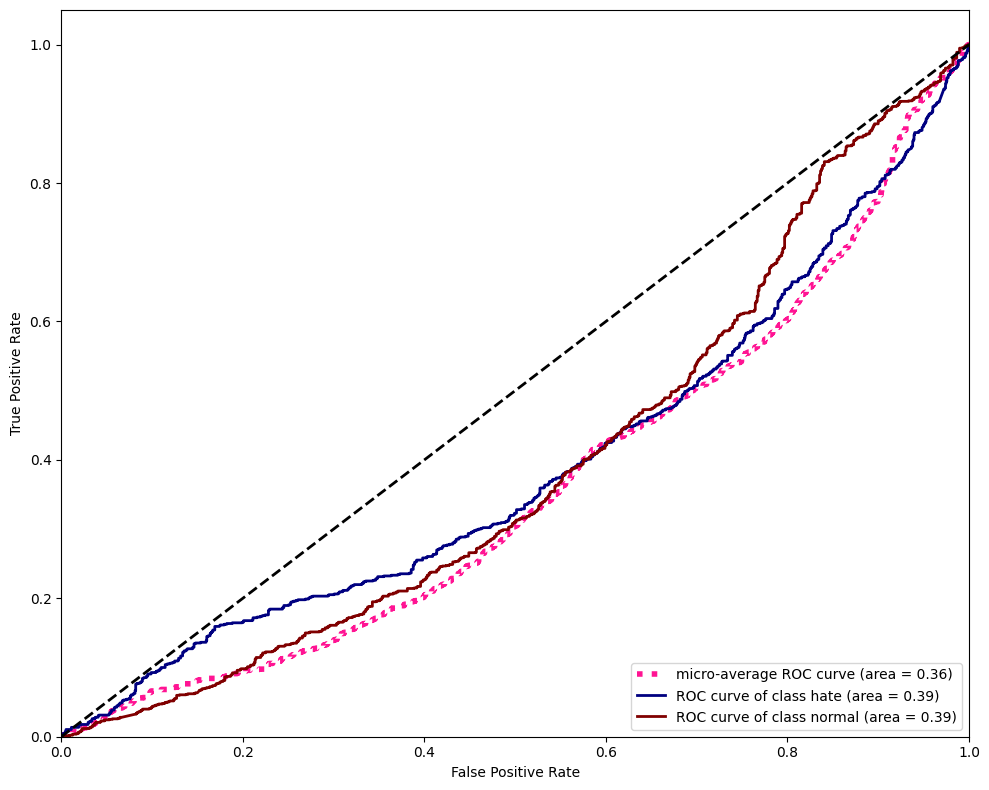

In [48]:
# Get the number of classes
n_classes = len(le.classes_)

# Convert y_test to one-hot encoding
y_test_one_hot = to_categorical(y_test, num_classes=n_classes)

# Compute ROC curve and ROC area for each class
fpr_best_cg = dict()
tpr_best_cg = dict()
roc_auc_best_cg = dict()
for i in range(n_classes):
    fpr_best_cg[i], tpr_best_cg[i], _ = roc_curve(y_test_one_hot[:, i], y_pred_probs_test_best_cg[:, i])
    roc_auc_best_cg[i] = auc(fpr_best_cg[i], tpr_best_cg[i])

# Compute micro-average ROC curve and ROC area
fpr_micro_best_cg, tpr_micro_best_cg, _ = roc_curve(y_test_one_hot.ravel(), y_pred_probs_test_best_cg.ravel())
roc_auc_micro_best_cg = auc(fpr_micro_best_cg, tpr_micro_best_cg)

# Plot all ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_micro_best_cg, tpr_micro_best_cg,
         label='micro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc_micro_best_cg),
         color='deeppink', linestyle=':', linewidth=4)

colors = plt.cm.get_cmap('jet', n_classes)
for i, color in zip(range(n_classes), colors(np.linspace(0, 1, n_classes))):
    plt.plot(fpr_best_cg[i], tpr_best_cg[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
                   ''.format(le.classes_[i], roc_auc_best_cg[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/CSNLP/Football/cnn_gru_roc.png')
plt.show()

In [49]:
model_cg.save('/content/drive/MyDrive/CSNLP/Football/cnn_gru.keras')

CNN + LSTM + GRU

In [ ]:
model_eeg = Sequential()

model_eeg.add(Conv1D(filters=64, kernel_size=5, activation='elu', input_shape=(X_train.shape[1], 1)))
model_eeg.add(BatchNormalization())
model_eeg.add(MaxPooling1D(pool_size=2))
model_eeg.add(Dropout(0.3))

model_eeg.add(Conv1D(filters=128, kernel_size=3, activation='elu'))
model_eeg.add(BatchNormalization())
model_eeg.add(MaxPooling1D(pool_size=2))
model_eeg.add(Dropout(0.4))

model_eeg.add(Conv1D(filters=256, kernel_size=3, activation='elu', kernel_regularizer=l2(0.01)))
model_eeg.add(BatchNormalization())
model_eeg.add(MaxPooling1D(pool_size=2))
model_eeg.add(Dropout(0.4))

model_eeg.add(LSTM(units=128, return_sequences=True))
model_eeg.add(Dropout(0.3))

model_eeg.add(LSTM(units=128, return_sequences=True))
model_eeg.add(Dropout(0.3))

model_eeg.add(GRU(units=128, return_sequences=False))
model_eeg.add(BatchNormalization())
model_eeg.add(Dropout(0.3))

model_eeg.add(Flatten())

model_eeg.add(Dense(128, activation='elu', kernel_regularizer=l2(0.01)))
model_eeg.add(Dropout(0.3))

model_eeg.add(Dense(len(le.classes_), activation='softmax'))

In [ ]:
model_eeg.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_eeg.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_26 (Conv1D)              │ (None, 1647, 64)       │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 1647, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_26 (MaxPooling1D) │ (None, 823, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_63 (Dropout)            │ (None, 823, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_27 (Conv1D)              │ (None, 821, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 821, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_27 (MaxPooling1D) │ (None, 410, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 410, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_28 (Conv1D)              │ (None, 408, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 408, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_28 (MaxPooling1D) │ (None, 204, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 204, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 204, 128)       │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_66 (Dropout)            │ (None, 204, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 204, 128)       │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_67 (Dropout)            │ (None, 204, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_8 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_68 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_69 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 2)              │           25

 Total params: 570,498 (2.18 MB)

 Trainable params: 569,346 (2.17 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [ ]:
X_val_cnn_lstm_gru = X_val.toarray().reshape(X_val.shape[0], X_val.shape[1], 1)
history_eeg = model_eeg.fit(X_train_1d, y_train, epochs=50, batch_size=32, validation_data=(X_val_cnn_lstm_gru, y_val))

Epoch 1/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.5436 - loss: 2.8868 - val_accuracy: 0.5851 - val_loss: 2.0168
Epoch 2/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - accuracy: 0.6031 - loss: 1.5508 - val_accuracy: 0.5825 - val_loss: 1.2872
Epoch 3/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.6319 - loss: 1.0087 - val_accuracy: 0.6197 - val_loss: 0.8817
Epoch 4/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.6451 - loss: 0.7996 - val_accuracy: 0.6379 - val_loss: 0.7444
Epoch 5/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - accuracy: 0.6629 - loss: 0.7154 - val_accuracy: 0.6137 - val_loss: 0.7241
Epoch 6/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - accuracy: 0.6684 - loss: 0.6820 - val_accuracy: 0.6474 - val_loss: 0.6786
Epoch 7/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.6539 - loss: 0.7090 - val_accuracy: 0.6422 - val_loss: 0.6874
Epoch 8/50
253/253 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - accuracy: 0.6655 - loss: 0.6965 - 

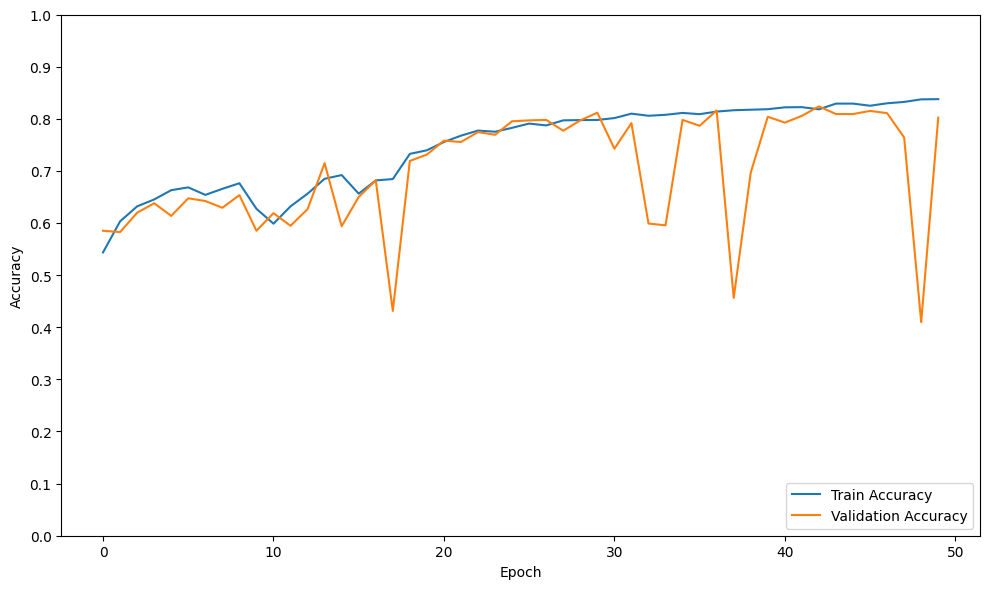

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))
plt.plot(history_eeg.history['accuracy'], label='Train Accuracy')
plt.plot(history_eeg.history['val_accuracy'], label='Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.yticks([i / 10 for i in range(11)])
plt.legend(loc='lower right')
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/CSNLP/Football/cnn_lstm_gru_accuracy.png')
plt.show()

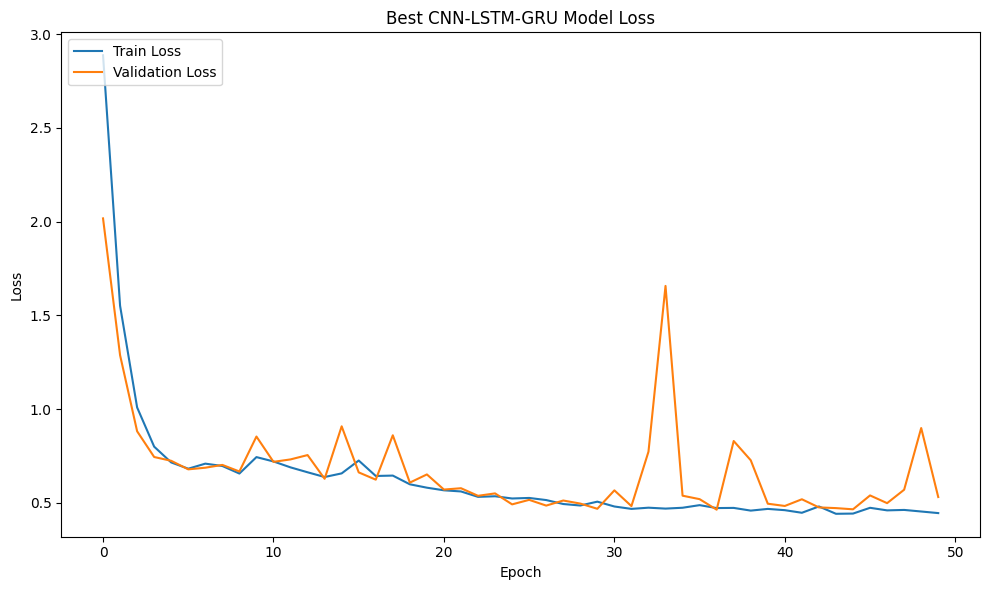

In [ ]:
# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history_eeg.history['loss'], label='Train Loss')
plt.plot(history_eeg.history['val_loss'], label='Validation Loss')
plt.title('Best CNN-LSTM-GRU Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/CSNLP/Football/cnn_lstm_gru_loss.png')
plt.show()

In [ ]:
# Predict probabilities on the training set for the best CNN-LSTM-GRU model
y_pred_probs_train_best_eeg = model_eeg.predict(X_train_1d)
# Convert probabilities to class labels
y_predict_best_eeg_train = np.argmax(y_pred_probs_train_best_eeg, axis=1)

# Compute confusion matrix for the best CNN-LSTM-GRU model on training data
cm_best_eeg_train = confusion_matrix(y_train, y_predict_best_eeg_train)
print(cm_best_eeg_train)

253/253 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step
[[3137  223]
 [1034 3702]]


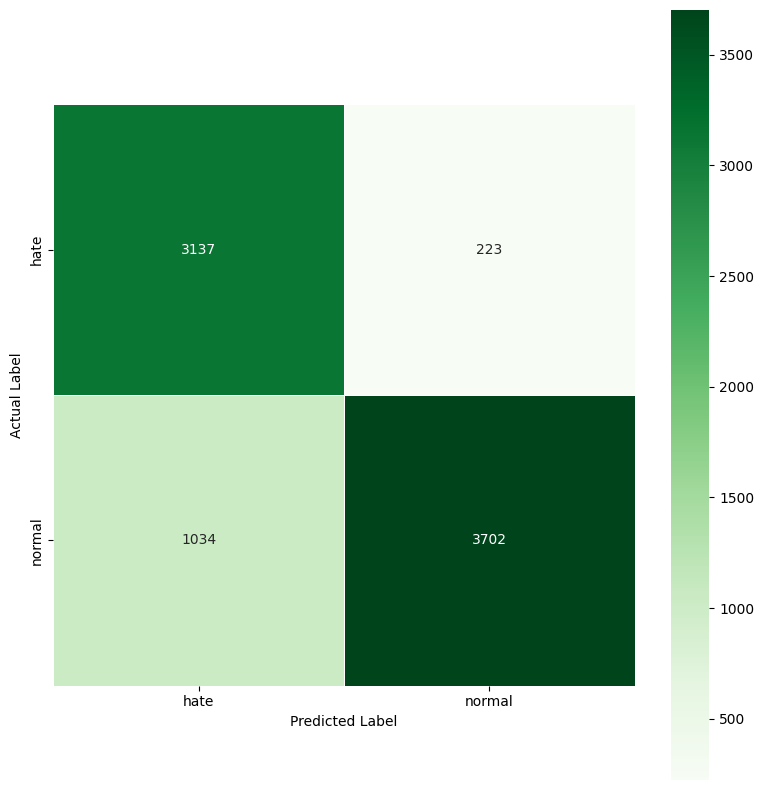

In [ ]:
plt.figure(figsize = (8,8))
sns.heatmap(cm_best_eeg_train, annot=True, fmt='d', linewidth = .5, square = True, cmap = "Greens",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/CSNLP/Football/cnn_lstm_gru_train_CM.png')
plt.show()

In [ ]:
report_best_eeg_train = classification_report(y_train, y_predict_best_eeg_train, target_names=le.classes_)
print("Best CNN-LSTM-GRU Train Report:\n", report_best_eeg_train)

Best CNN-LSTM-GRU Train Report:
               precision    recall  f1-score   support

        hate       0.75      0.93      0.83      3360
      normal       0.94      0.78      0.85      4736

    accuracy                           0.84      8096
   macro avg       0.85      0.86      0.84      8096
weighted avg       0.86      0.84      0.85      8096



In [ ]:
# Predict probabilities on the test set for the best CNN-LSTM-GRU model
y_pred_probs_test_best_eeg = model_eeg.predict(X_test_1d)
# Convert probabilities to class labels
y_predict_best_eeg_test = np.argmax(y_pred_probs_test_best_eeg, axis=1)

# Compute confusion matrix for the best CNN-LSTM-GRU model on test data
cm_best_eeg_test = confusion_matrix(y_test, y_predict_best_eeg_test)
print(cm_best_eeg_test)

73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step
[[ 836  124]
 [ 339 1015]]


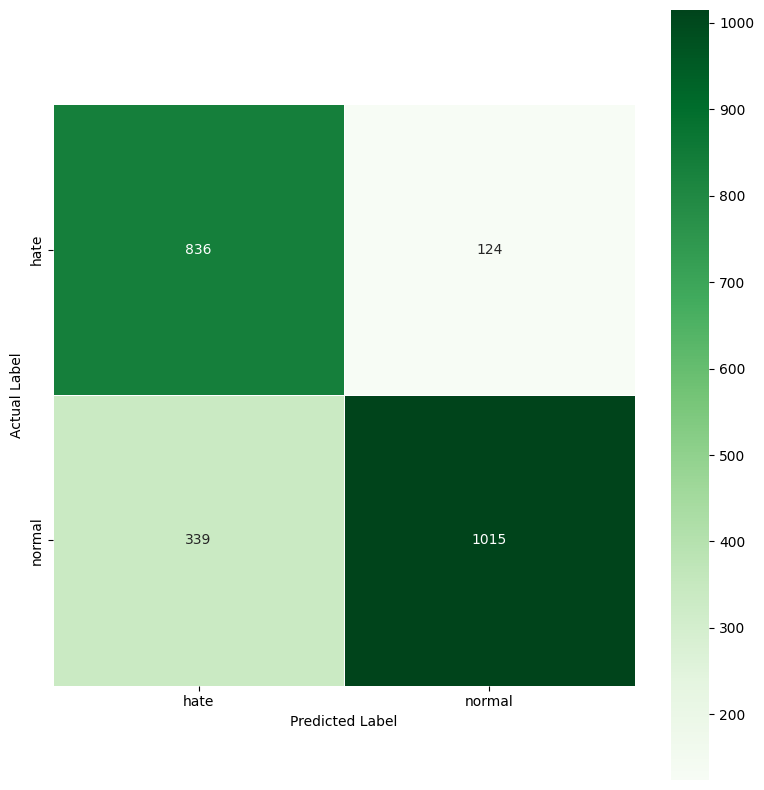

In [ ]:
plt.figure(figsize = (8,8))
sns.heatmap(cm_best_eeg_test, annot=True, fmt='d', linewidth = .5, square = True, cmap = "Greens",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/CSNLP/Football/cnn_lstm_gru_test_CM.png')
plt.show()

In [ ]:
report_best_eeg_test = classification_report(y_test, y_predict_best_eeg_test, target_names=le.classes_)
print("Best CNN-LSTM-GRU Test Report:\n", report_best_eeg_test)

Best CNN-LSTM-GRU Test Report:
               precision    recall  f1-score   support

        hate       0.71      0.87      0.78       960
      normal       0.89      0.75      0.81      1354

    accuracy                           0.80      2314
   macro avg       0.80      0.81      0.80      2314
weighted avg       0.82      0.80      0.80      2314



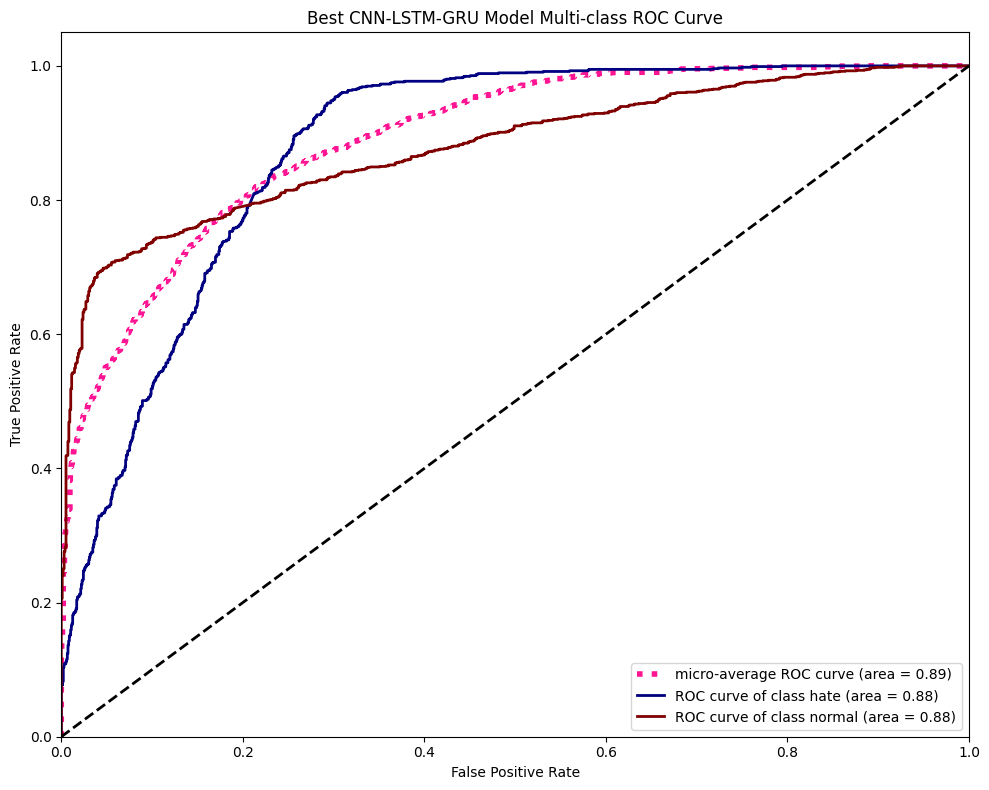

In [ ]:
# Get the number of classes
n_classes = len(le.classes_)

# Convert y_test to one-hot encoding
y_test_one_hot = to_categorical(y_test, num_classes=n_classes)

# Compute ROC curve and ROC area for each class
fpr_best_eeg = dict()
tpr_best_eeg = dict()
roc_auc_best_eeg = dict()
for i in range(n_classes):
    fpr_best_eeg[i], tpr_best_eeg[i], _ = roc_curve(y_test_one_hot[:, i], y_pred_probs_test_best_eeg[:, i])
    roc_auc_best_eeg[i] = auc(fpr_best_eeg[i], tpr_best_eeg[i])

# Compute micro-average ROC curve and ROC area
fpr_micro_best_eeg, tpr_micro_best_eeg, _ = roc_curve(y_test_one_hot.ravel(), y_pred_probs_test_best_eeg.ravel())
roc_auc_micro_best_eeg = auc(fpr_micro_best_eeg, tpr_micro_best_eeg)

# Plot all ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_micro_best_eeg, tpr_micro_best_eeg,
         label='micro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc_micro_best_eeg),
         color='deeppink', linestyle=':', linewidth=4)

colors = plt.cm.get_cmap('jet', n_classes)
for i, color in zip(range(n_classes), colors(np.linspace(0, 1, n_classes))):
    plt.plot(fpr_best_eeg[i], tpr_best_eeg[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
                   ''.format(le.classes_[i], roc_auc_best_eeg[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Best CNN-LSTM-GRU Model Multi-class ROC Curve')
plt.legend(loc="lower right")
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/CSNLP/Football/cnn_lstm_gru_roc.png')
plt.show()

In [ ]:
model_eeg.save('/content/drive/MyDrive/CSNLP/Football/cnn_lstm_gru.keras')